## 📈 Stock Market Analysis: US Big Five Tech Companies

This notebook aims to analyse stock market data for the Big Five US technology companies. By exploring historical price movements, we develop a general understanding of how stock prices have performed over time, as well as how trading volume and volatility vary across companies and periods.

Beyond descriptive analysis, we apply statistical testing to assess whether there are any statistically significant relationships within the data. Finally, we extend the analysis by building a range of machine learning models, spanning:

- **Time series forecasting**
- **Survival Analysis**
- **Ranking approaches**


Together, these methods provide a comprehensive, data-driven view of performance, behaviour, and predictability within large-cap US tech stocks.

Data can be found in the https://pypi.org/project/yfinance/ API. Details on how to extract will be in the README file

# Imports

In [2]:
import warnings
import pandas as pd
import helper_functions as hf
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import duckdb
import lightgbm as lgb

from scipy.stats import binomtest
from statsmodels.tsa.seasonal import seasonal_decompose
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from lifelines import KaplanMeierFitter, CoxPHFitter, WeibullFitter
from sklearn.metrics import average_precision_score
from sksurv.util import Surv


pd.set_option('display.max_columns', None)

pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))
warnings.filterwarnings('ignore')

In [3]:
start_date = "2010-01-01"
end_date = "2025-12-01"
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]

df = pd.DataFrame(columns=['date', 'open', 'high', 'low', 'close', 'volume', 'ticker'])

for ticker in tickers:
    df = pd.concat([df, hf.create_ticker_df(ticker, start_date, end_date)],ignore_index=True)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
df['ticker'].value_counts()

ticker
AAPL     4002
MSFT     4002
AMZN     4002
GOOGL    4002
META     3403
Name: count, dtype: int64

In [5]:
df.dtypes

date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume           float64
ticker            object
dtype: object

# Checking Data Quality

In [6]:
df.describe()

,date,open,high,low,close,volume
count,19411,"19,411.00","19,411.00","19,411.00","19,411.00","19,411.00"
mean,2018-02-28 18:54:17.081036544,114.87,116.15,113.57,114.90,85.69
min,2010-01-04 00:00:00,5.30,5.56,5.29,5.43,4.73
25%,2014-05-05 00:00:00,25.54,25.77,25.26,25.54,26.68
50%,2018-03-12 00:00:00,70.75,71.54,69.61,70.80,47.00
75%,2022-01-18 00:00:00,165.59,167.34,163.52,165.51,88.00
max,2025-11-28 00:00:00,789.97,795.06,779.66,788.82,"1,881.00"
std,NaN,124.23,125.57,122.76,124.20,125.64


There doesn't appear to be any major discrepancies in the data. However, it is worth noting that **Meta** has a later minimum date compared to the other companies. This is expected, as Meta only floated on the stock market on **18 May 2012**, whereas the remaining companies were already publicly listed prior to **2010**.


In [7]:
df.groupby(['ticker']).describe().T

ticker                                 AAPL                           AMZN  \
date   count                           4002                           4002   
       mean   2017-12-14 13:33:33.193403136  2017-12-14 13:33:33.193403136   
       min              2010-01-04 00:00:00            2010-01-04 00:00:00   
       25%              2013-12-23 06:00:00            2013-12-23 06:00:00   
       50%              2017-12-12 12:00:00            2017-12-12 12:00:00   
       75%              2021-12-02 18:00:00            2021-12-02 18:00:00   
       max              2025-11-28 00:00:00            2025-11-28 00:00:00   
       std                              NaN                            NaN   
open   count                       4,002.00                       4,002.00   
       mean                           76.35                          79.73   
       min                             5.77                           5.30   
       25%                            18.16                          15.40   
       50%                            38.20                          58.60   
       75%                           141.48                         138.93   
       max                           277.26                         255.36   
       std                            73.68                          68.39   
high   count                       4,002.00                       4,002.00   
       mean                           77.18                          80.64   
       min                             5.88                           5.56   
       25%                            18.32                          15.61   
       50%                            38.54                          58.97   
       75%                           143.61                         140.47   
       max                           280.38                         258.60   
       std                            74.49                          69.15   
low    count                       4,002.00                       4,002.00   
       mean                           75.59                          78.74   
       min                             5.71                           5.29   
       25%                            18.01                          15.23   
       50%                            37.79                          58.10   
       75%                           140.24                         136.97   
       max                           276.63                         252.90   
       std                            72.96                          67.54   
close  count                       4,002.00                       4,002.00   
       mean                           76.42                          79.71   
       min                             5.76                           5.43   
       25%                            18.19                          15.42   
       50%                            38.21                          58.73   
       75%                           142.17                         138.23   
       max                           278.85                         254.00   
       std                            73.77                          68.35   
volume count                       4,002.00                       4,002.00   
       mean                          219.97                          81.05   
       min                            20.14                          15.01   
       25%                            78.68                          50.45   
       50%                           131.71                          67.98   
       75%                           291.26                          96.64   
       max                         1,881.00                         848.42   
       std                           215.67                          51.18   

ticker                                GOOGL                           META  \
date   count                           4002                           3403   
       mean   2017-12

In [8]:
df.isna().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
ticker    0
dtype: int64

In [9]:
print(f"Duplicated Records: {round(df.duplicated().sum()/len(df),3)*100}% \nTotal Record Dupes: {df.duplicated().sum()}\nTotal Record: {len(df)}")

Duplicated Records: 0.0% 
Total Record Dupes: 0
Total Record: 19411


Great! There's no duplicate records, missing data or poor data quality. Let's try enrich our dataset by adding some more features.

# Feature Engineering

In [10]:
df['close_pct_daily_change'] = (df['close'] - df['open']) / df['open'] * 100
df['vol_pct_daily_change'] = (df.groupby('ticker')['volume'].pct_change())

df["vol_pct_5d"] = (df.groupby("ticker")["vol_pct_daily_change"].rolling(5).std().reset_index(level=0, drop=True))

df["day_of_month"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month

df["up_day"] = (df["close_pct_daily_change"] > 0).astype(int)


In [11]:
df.head(10)

,date,open,high,low,close,volume,ticker,close_pct_daily_change,vol_pct_daily_change,vol_pct_5d,day_of_month,day_of_week,week_of_year,month,up_day
0,2010-01-04,6.40,6.43,6.37,6.42,493.73,AAPL,0.27,NaN,NaN,4,0,1,1,1
1,2010-01-05,6.44,6.47,6.40,6.43,601.90,AAPL,-0.10,0.22,NaN,5,1,1,1,0
2,2010-01-06,6.43,6.45,6.32,6.33,552.16,AAPL,-1.59,-0.08,NaN,6,2,1,1,0
3,2010-01-07,6.35,6.36,6.27,6.32,477.13,AAPL,-0.55,-0.14,NaN,7,3,1,1,0
4,2010-01-08,6.31,6.36,6.27,6.36,447.61,AAPL,0.80,-0.06,NaN,8,4,1,1,1
5,2010-01-11,6.38,6.39,6.25,6.30,462.23,AAPL,-1.26,0.03,0.14,11,0,2,1,0
6,2010-01-12,6.27,6.29,6.19,6.23,594.46,AAPL,-0.70,0.29,0.17,12,1,2,1,0
7,2010-01-13,6.23,6.33,6.12,6.32,605.89,AAPL,1.34,0.02,0.16,13,2,2,1,1
8,2010-01-14,6.30,6.31,6.27,6.28,432.89,AAPL,-0.32,-0.29,0.21,14,3,2,1,0
9,2010-01-15,6.33,6.35,6.17,6.18,594.07,AAPL,-2.37,0.37,0.26,15,4,2,1,0


# Exploratory Data Analysis

In [12]:
df.groupby(['ticker']).agg(avg_vol=('volume', 'mean'))

,avg_vol
ticker,
AAPL,219.97
AMZN,81.05
GOOGL,55.07
META,28.42
MSFT,35.37


Text(0.5, 1.0, 'Close Prices by Ticker')

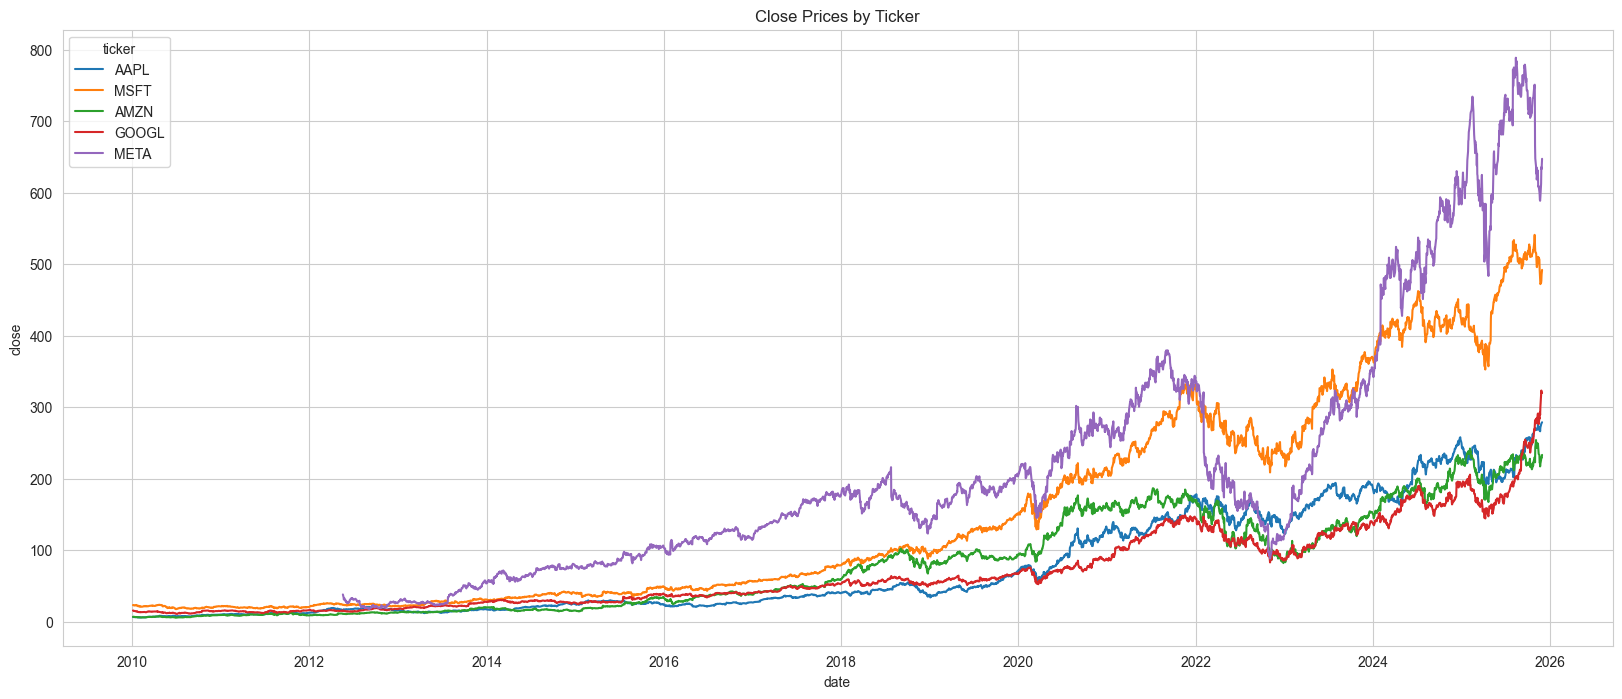

In [13]:
plt.figure(figsize=(20, 8))

sns.lineplot(data=df, x='date', y='close', hue='ticker').set_title("Close Prices by Ticker")

The stock prices for the Big Five companies have grown massively since 2010, so it's very hard to compare the percent of growth or the closing prices between 2010 and 2020. So let's take a log scale of our y-axis to make it more interpretable.

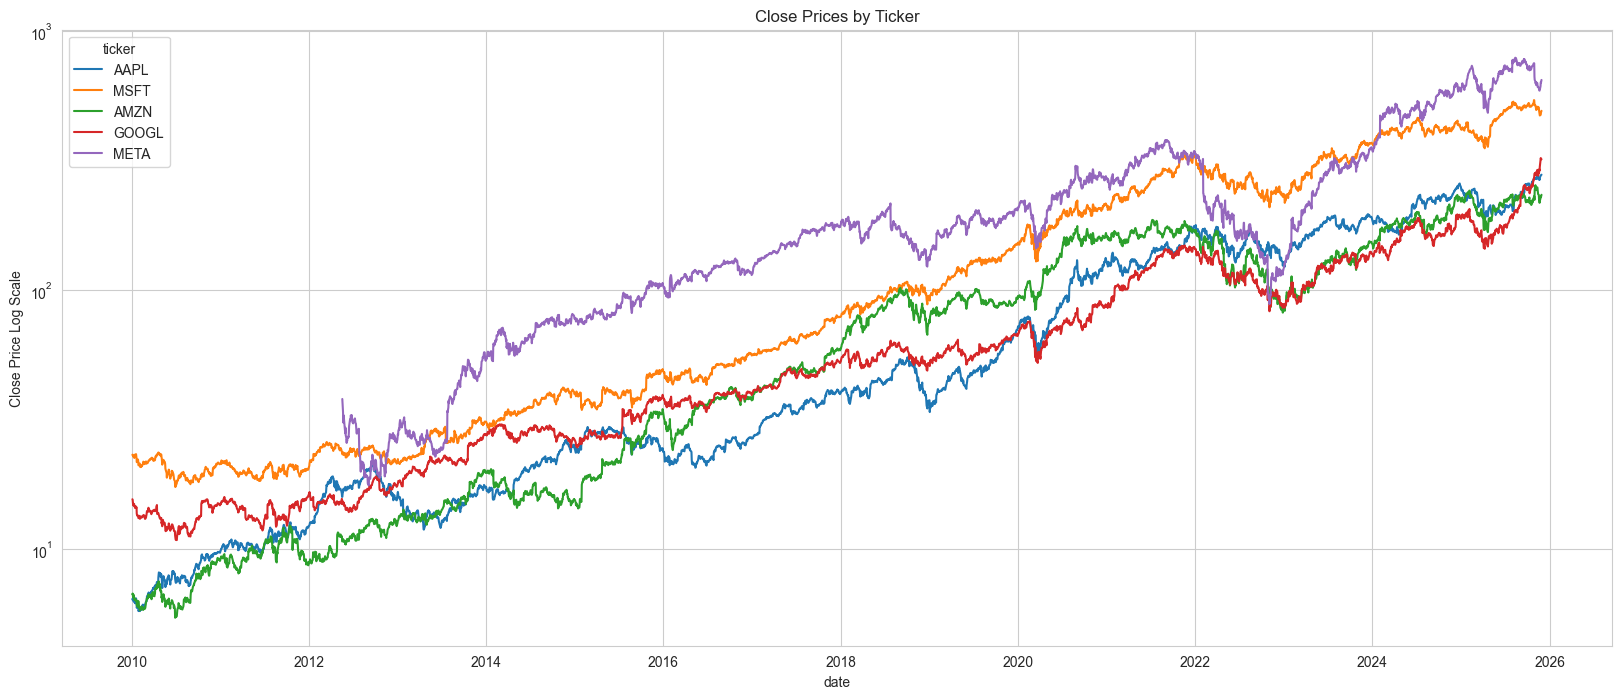

In [14]:
plt.figure(figsize=(20, 8))

ax = sns.lineplot(data=df, x='date', y='close', hue='ticker')
ax.set_title("Close Prices by Ticker")
ax.set_ylabel("Close Price Log Scale")

ax.set_yscale("log")

plt.show()


Looking at close prices on a **log scale** we can see a few patterns. The most obvious being a **strong upward trend** across all of our tickers. There is no obvious cyclical behaviour and we are almost certainly not seeing any seasonality in the data.

These observations will help guide our **time series forecasting choices** later on in the machine learning section of this notebook.

Now let’s zoom in on the time series and see whether behaviour changes when we break it down by month, day of the month,  day of the week.

In particular, we want to explore whether there are any consistent patterns at the **beginning or end of the month**, and whether certain days tend to perform better or worse than others in terms of **price increases or decreases**.




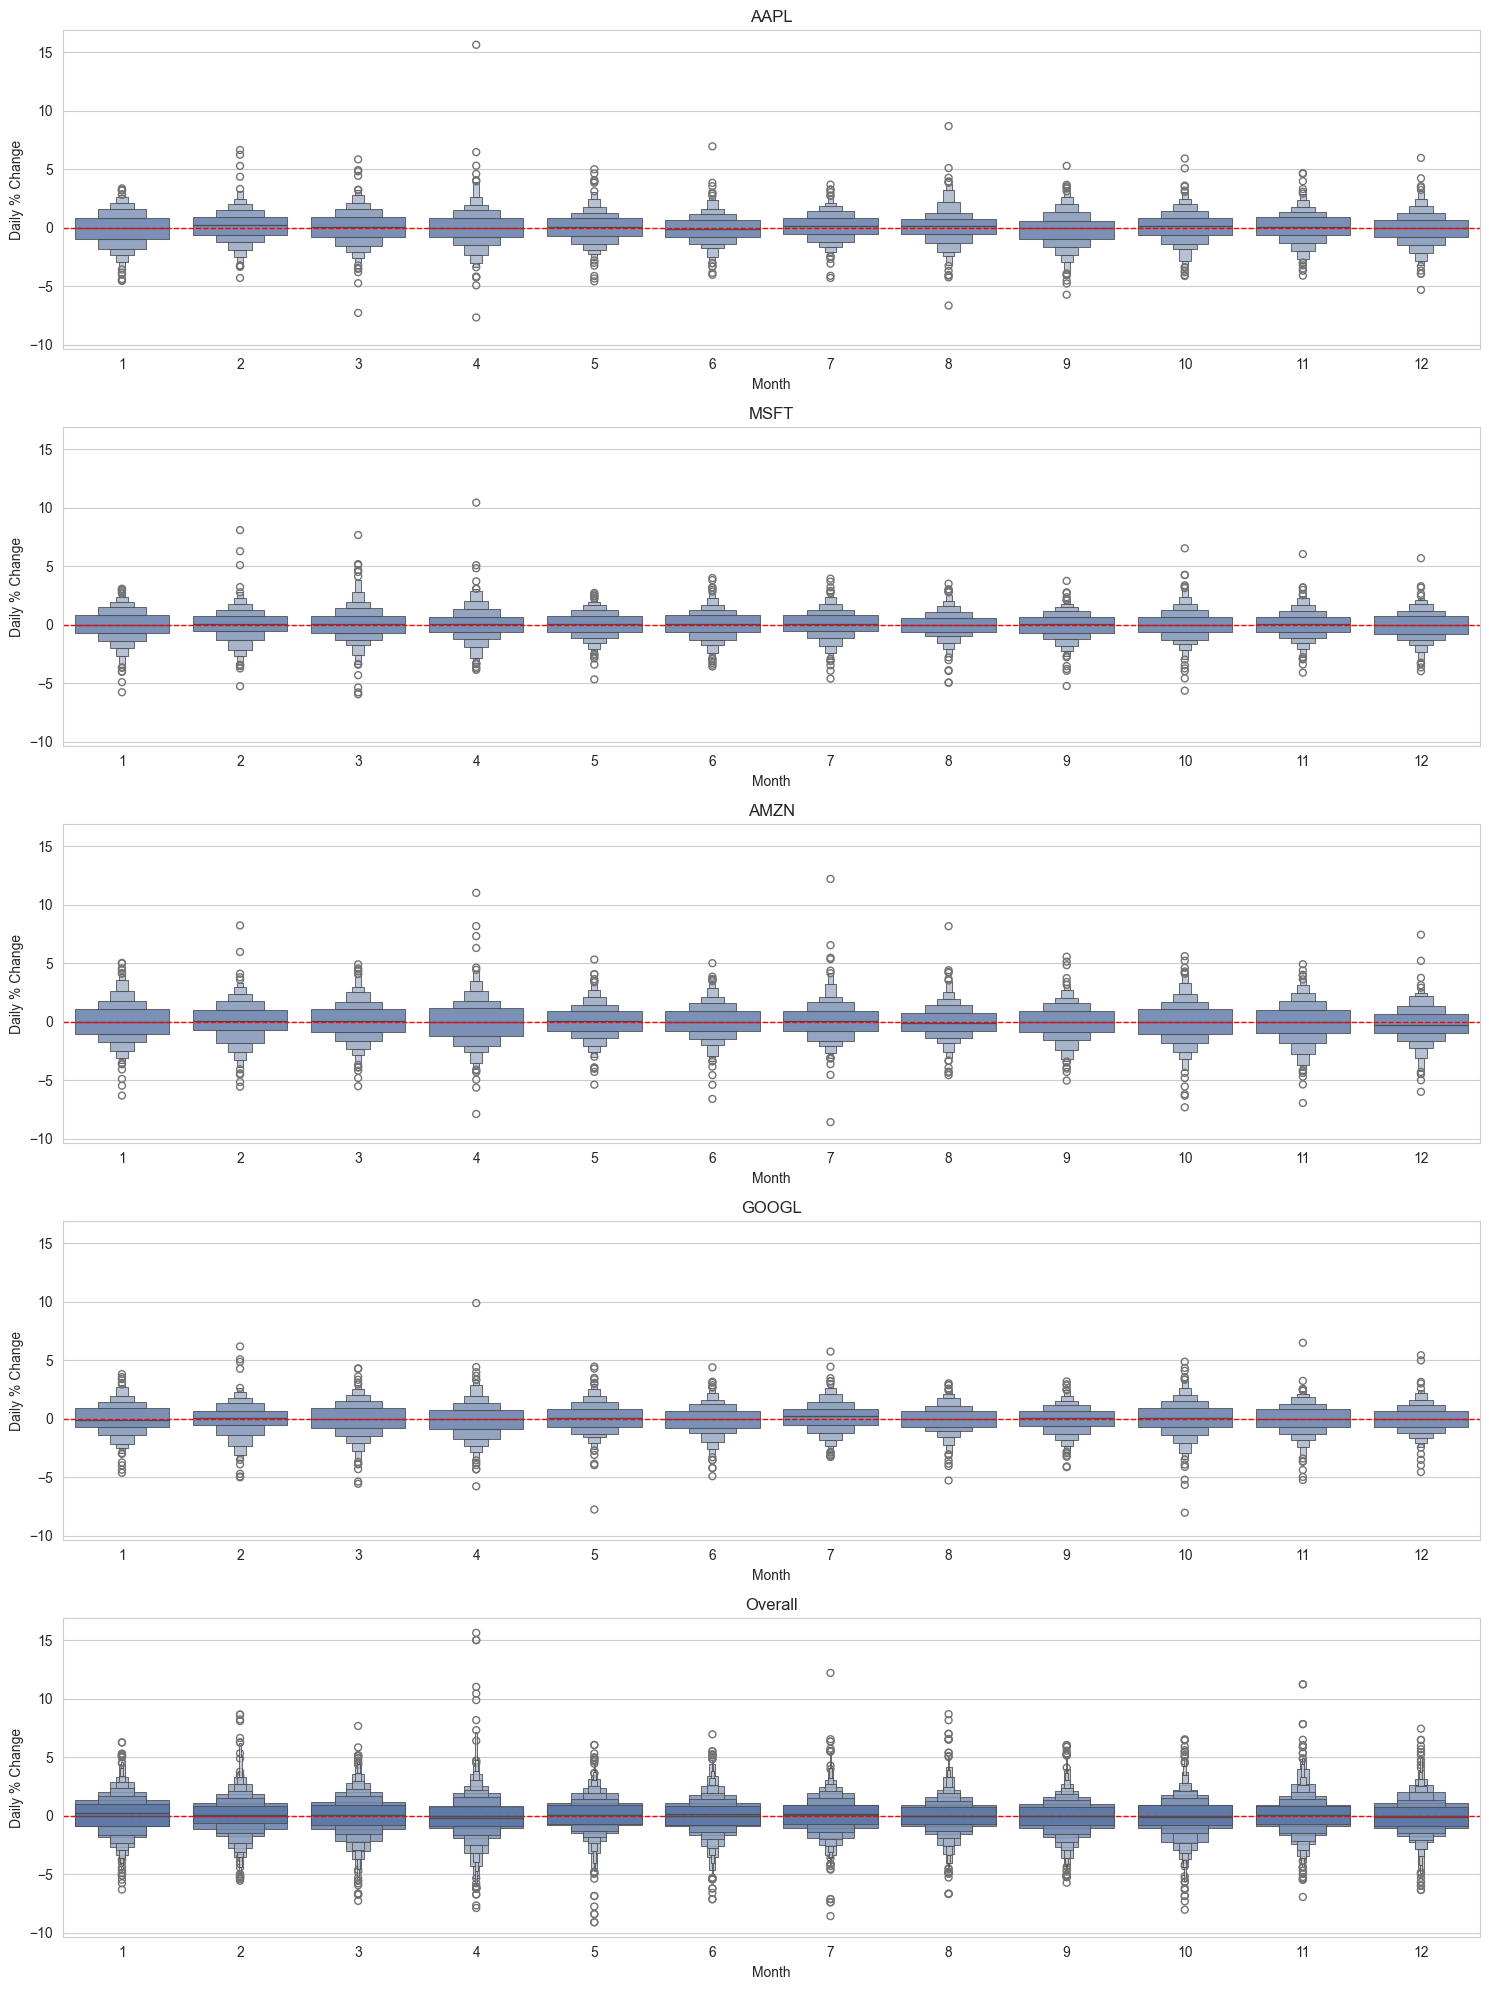

In [15]:
fig, axes = plt.subplots(len(tickers), 1, figsize=(15, 4 * len(tickers)), sharey=True)

for ax, ticker in zip(axes, tickers):
    data = df[df["ticker"] == ticker]

    sns.boxenplot(data=data,x="month",y="close_pct_daily_change",color='#4C72B0', alpha=0.8,ax=ax)

    ax.set_title(ticker)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("Month")
    ax.set_ylabel("Daily % Change")

sns.boxenplot(data=df,x="month",y="close_pct_daily_change",color='#4C72B0', alpha=0.8,ax=ax)
ax.set_title("Overall")

plt.tight_layout()
plt.show()


When we look at **price changes by ticker and overall across each month**, there don’t appear to be any standout months in particular. The **median return** for most months sits very close to zero, suggesting fairly balanced behaviour over time.

That said, we do observe a number of **outliers**. For example, month **4 (April)** shows some extremely high returns alongside some very large losses. This likely lines up with the **2020 COVID lockdown period**, where we saw a sharp market crash followed by a strong recovery.

Outside of these exceptional periods, there doesn’t seem to be any clear **monthly bias** that consistently delivers higher or lower returns compared to the rest.


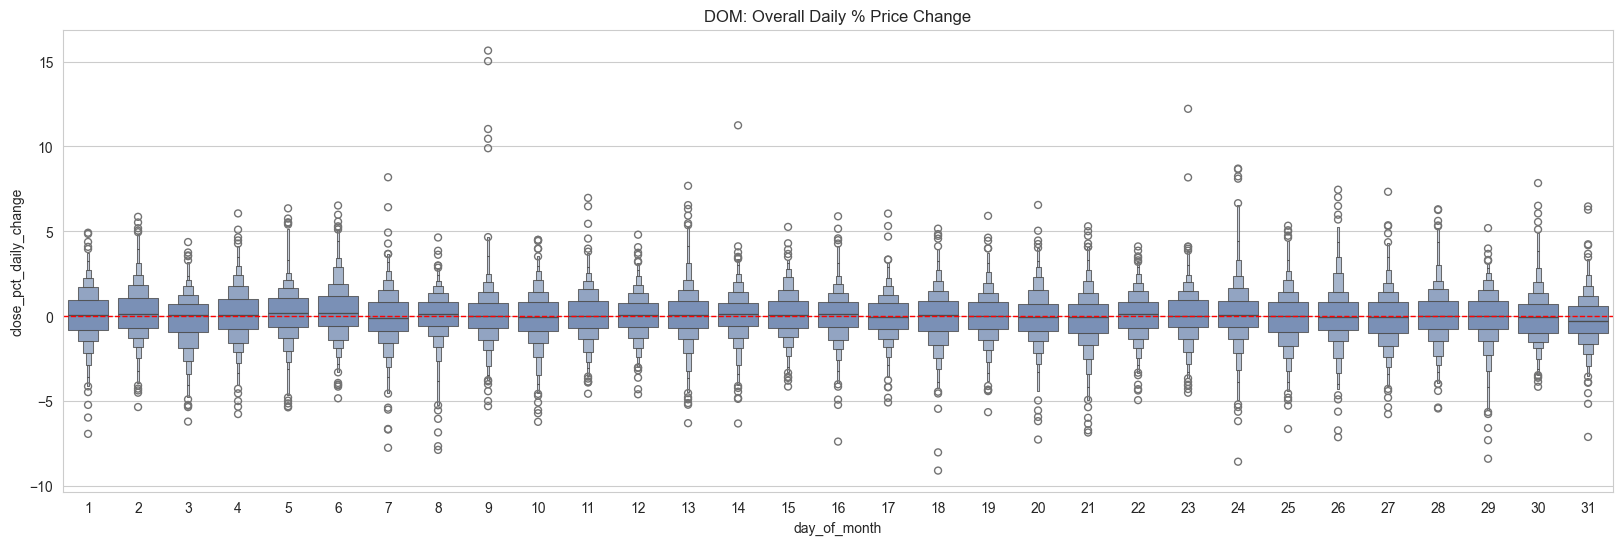

In [16]:
plt.figure(figsize=(20, 6))

ax = sns.boxenplot(
    data=df,
    x="day_of_month",
    y="close_pct_daily_change",
    color="#4C72B0",
    alpha=0.8
)

ax.set_title("DOM: Overall Daily % Price Change")
ax.axhline(0, color="red", linestyle="--", linewidth=1)

plt.show()

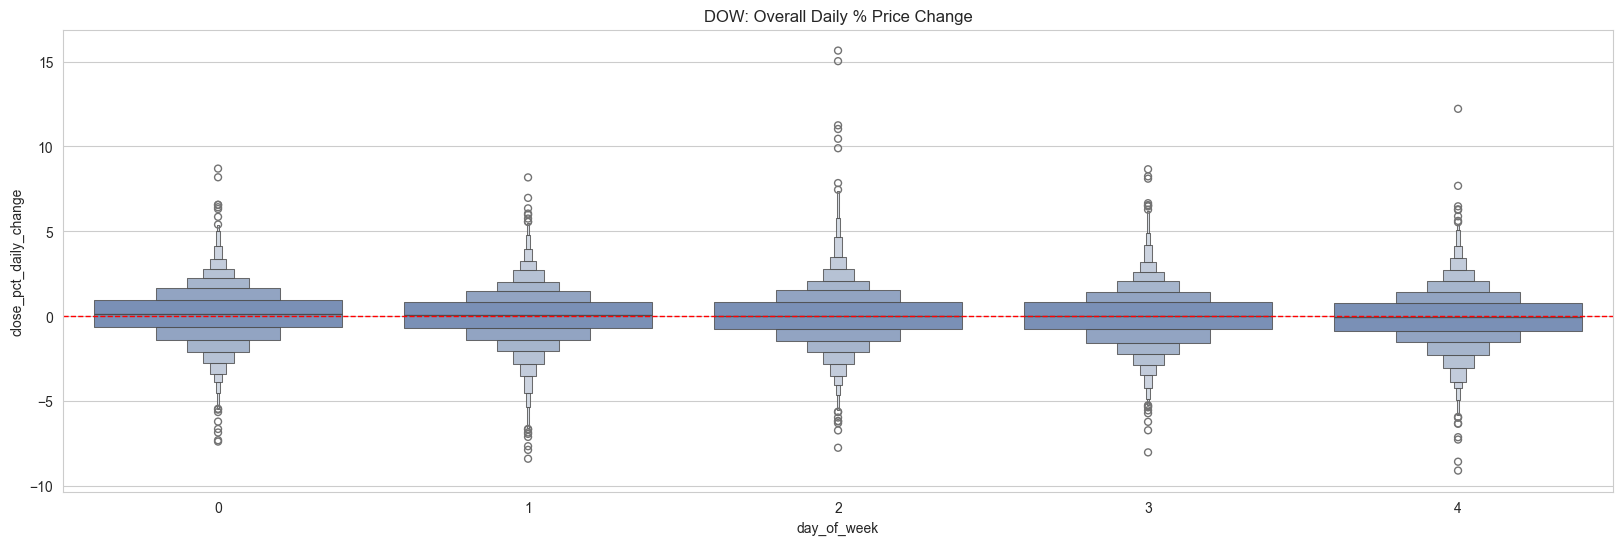

In [17]:
plt.figure(figsize=(20, 6))

ax = sns.boxenplot(
    data=df,
    x="day_of_week",
    y="close_pct_daily_change",
    color="#4C72B0",
    alpha=0.8
)

ax.set_title("DOW: Overall Daily % Price Change")
ax.axhline(0, color="red", linestyle="--", linewidth=1)

plt.show()


A similar story holds when we look at **days of the month**. Overall, there are no strong or systematic patterns. That said, there is a noticeable **outlier on the 31st**. It’s worth remembering that the 31st only occurs in a subset of months — January, March, May, July, August, October, and December.

For the 31st, the **median value sits clearly below zero**, which suggests there may be some bias linked to specific trading periods. December is a good example here, where reduced liquidity and holiday effects around Christmas could be influencing returns. This is something we could explore further if needed.

Looking at **days of the week**, we see that **0 (Monday)** is very slightly above zero. This hints at a potential **positive Monday bias**, although the effect looks small. We’ll dig into this in more detail in later on in the analysis.


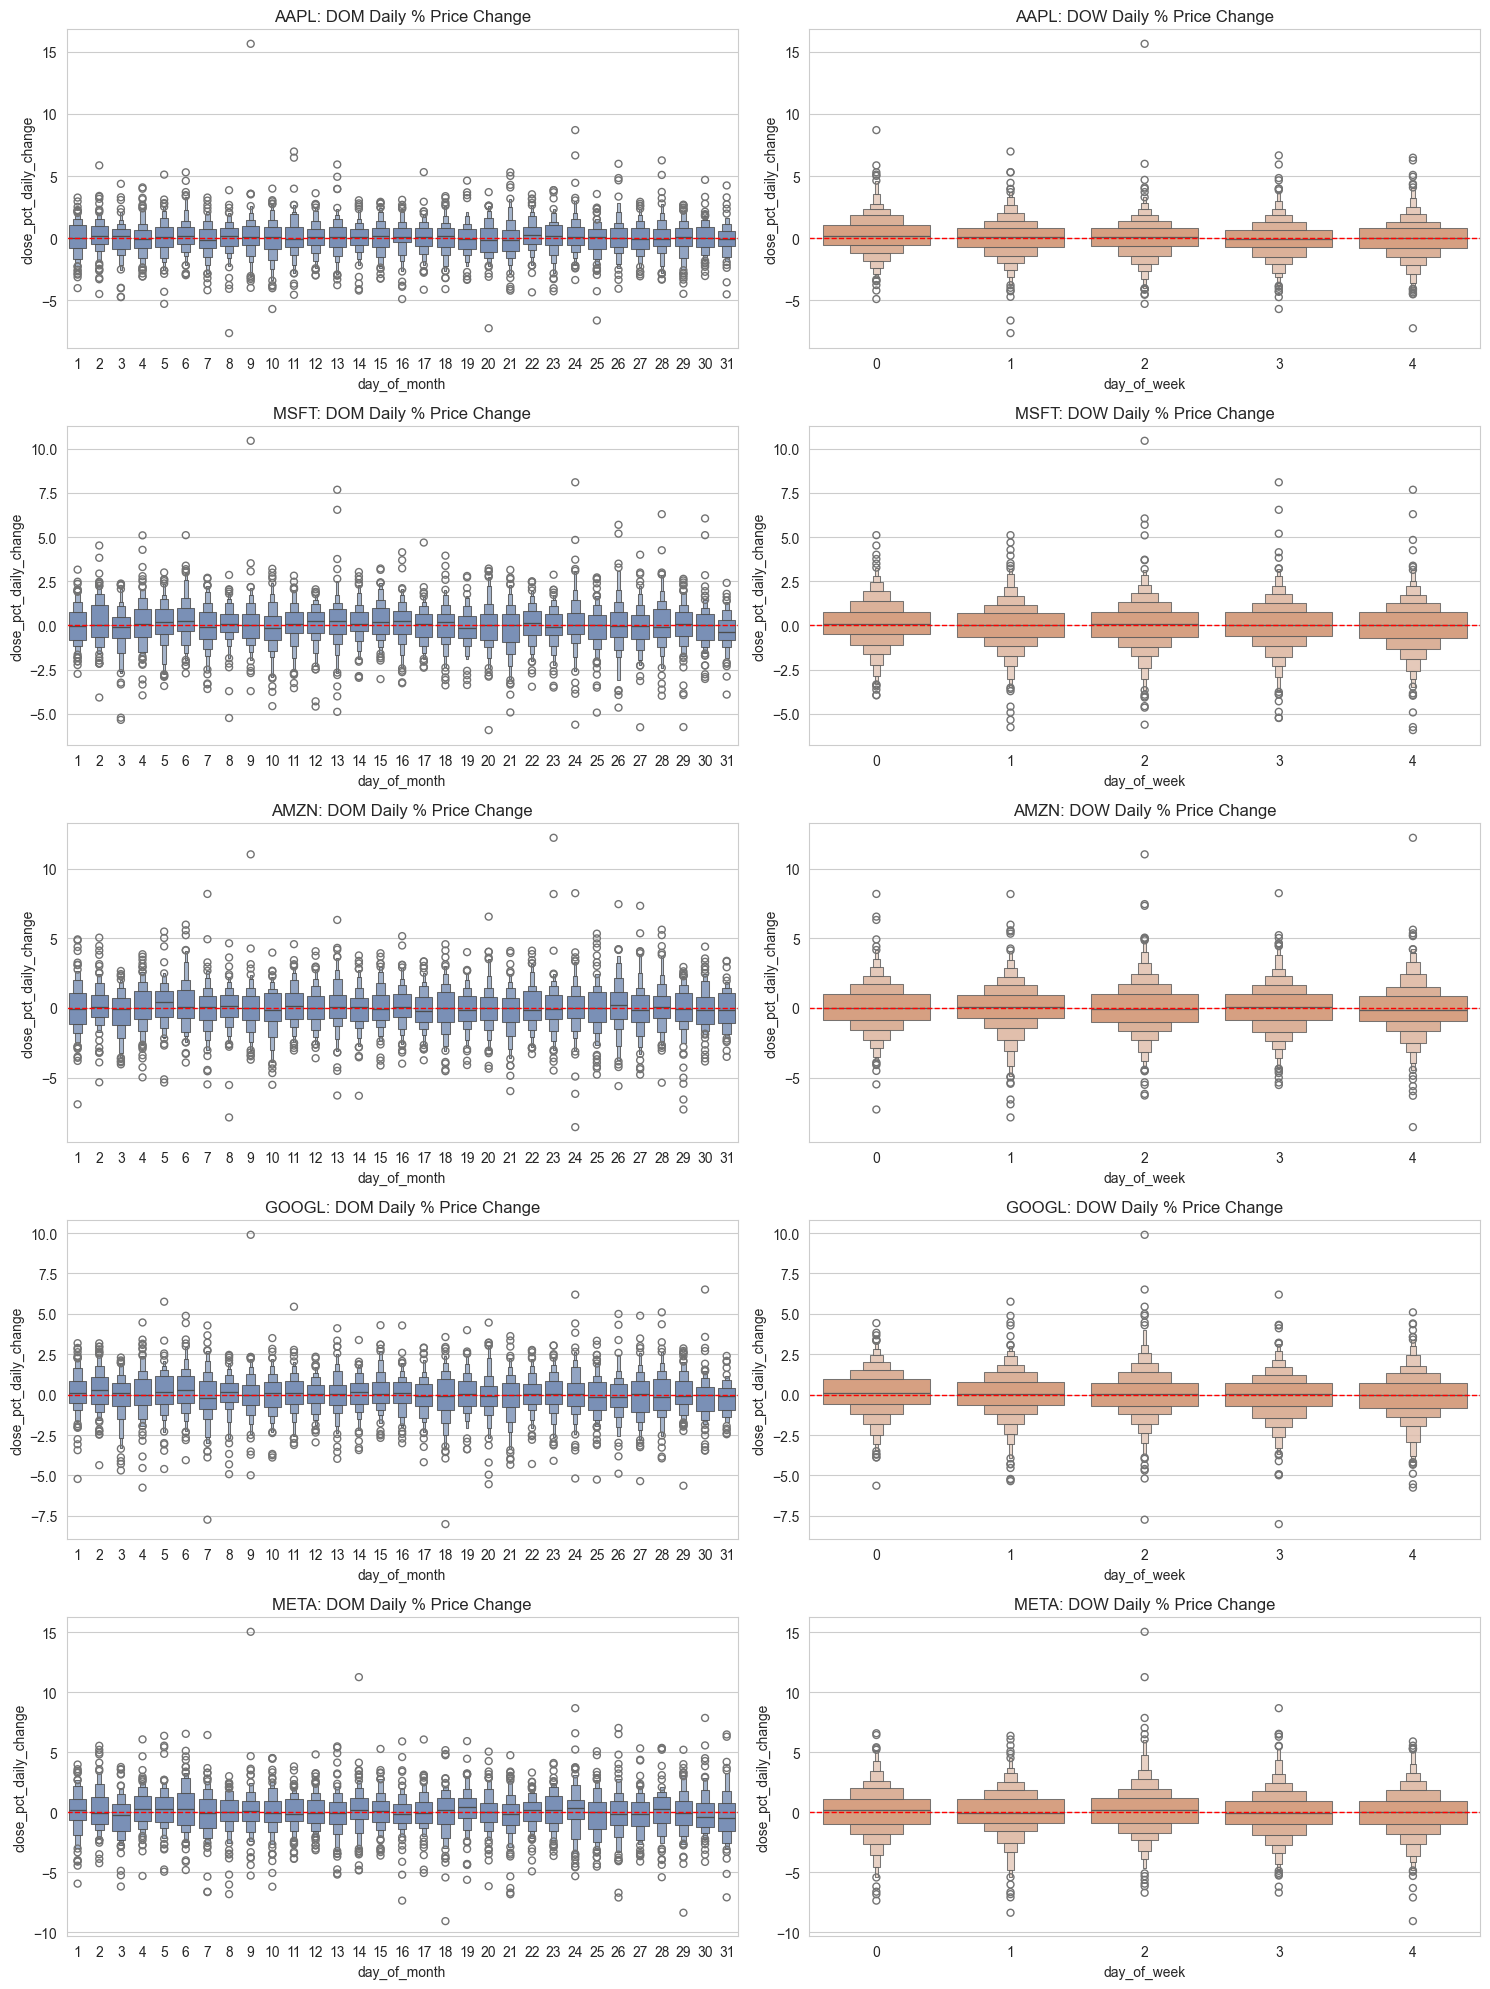

In [18]:
fig, ax = plt.subplots(len(tickers), 2, figsize=(15, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    data = df[df["ticker"] == ticker]

    sns.boxenplot(data=data,x="day_of_month",y="close_pct_daily_change",ax=ax[i, 0],color='#4C72B0', alpha=0.8)
    ax[i, 0].set_title(f"{ticker}: DOM Daily % Price Change")
    ax[i, 0].axhline(0, color="red", linestyle="--", linewidth=1)

    sns.boxenplot(data=data,x="day_of_week",y="close_pct_daily_change",ax=ax[i, 1], color='#DD8452', alpha=0.8)
    ax[i, 1].set_title(f"{ticker}: DOW Daily % Price Change")
    ax[i, 1].axhline(0, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

It was a little bit difficult to see the difference between the different days, months, and weeks in the box and plots. So what we'll do is we'll take the median value of returns and we'll plot them onto a heatmap and see if there's anything that stands out to us.

In [19]:
dom_summary = (df.groupby(['ticker', 'day_of_month']).agg(median_pct_change=('close_pct_daily_change', 'median')).reset_index())
dom_summary = dom_summary.pivot(index='ticker',columns='day_of_month',values='median_pct_change')

dow_summary = (df.groupby(['ticker', 'day_of_week']).agg(median_pct_change=('close_pct_daily_change', 'median')).reset_index())
dow_summary = dow_summary.pivot(index='ticker',columns='day_of_week',values='median_pct_change')


Text(0.5, 1.0, 'Median % Daily Price Change by Day of Month')

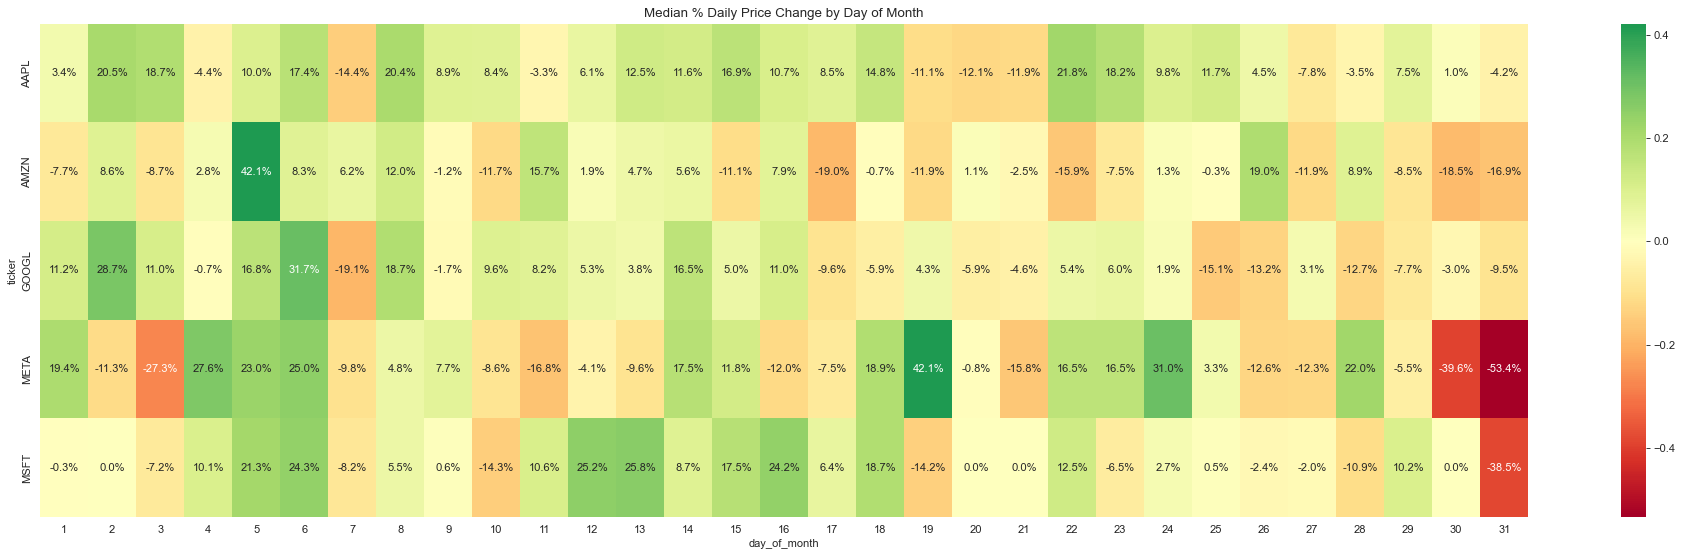

In [20]:
plt.figure(figsize=(30, 8), dpi=80)

sns.heatmap(
    dom_summary,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    center=0,
    annot_kws={"size": 10}
).set_title("Median % Daily Price Change by Day of Month")



Nothing particualy interesting here, but the 30th and 31st stand out like they did in the boxenplots!

Text(0.5, 1.0, 'Median % Daily Price Change by Day of Week')

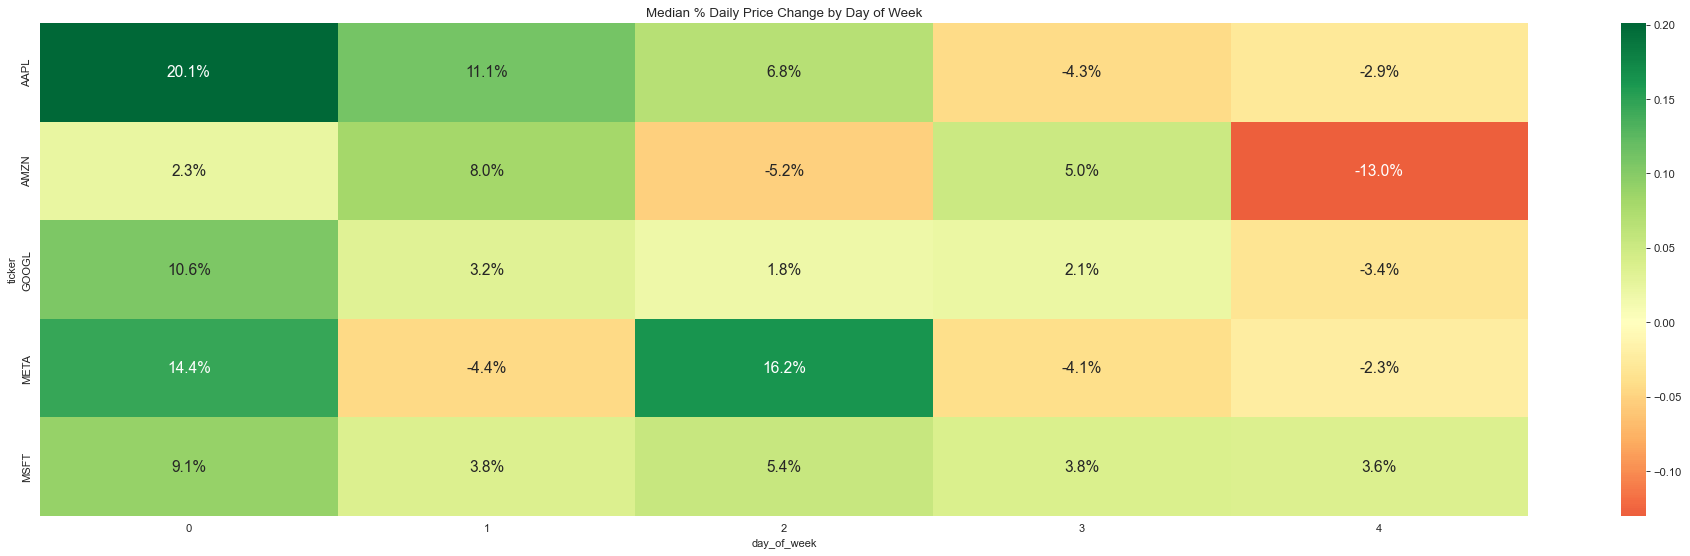

In [21]:
plt.figure(figsize=(30, 8), dpi=80)

sns.heatmap(
    dow_summary,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    center=0,
    annot_kws={"size": 14}
).set_title("Median % Daily Price Change by Day of Week")



This is really interesting the **heatmap** makes certain patterns stand out much more clearly than the box plots, and it confirms our earlier suspicion that there may be a **Monday bias**. The highest market returns tend to occur on **Monday (represented by 0)**.

Even more interestingly, the **worst market returns** appear to cluster around **Friday**. One possible explanation is that Monday’s performance could be a reaction to Friday’s close, or that **positive news released over the weekend** gets priced in when markets open on Monday.

Either way, this is a genuinely interesting finding and one that’s worth keeping in mind as we move into deeper analysis.


Text(0.5, 1.0, 'Volume Density Distribution by Ticker')

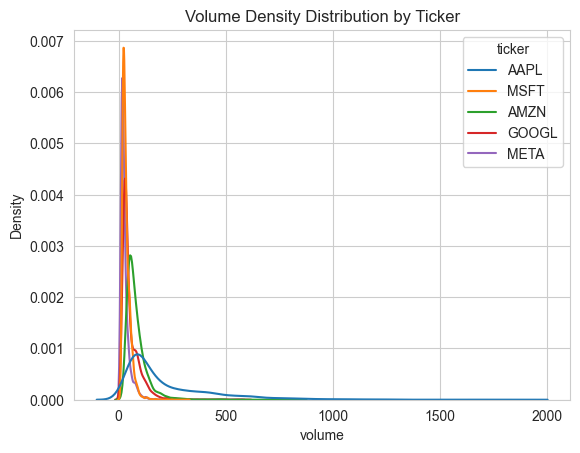

In [22]:
sns.kdeplot(data=df, x='volume', hue='ticker').set_title("Volume Density Distribution by Ticker")

That's a huge skew of trading volume. We can't make anything out of this chart with taking a log of volume.

In [23]:
df["log_volume"] = np.log10(df["volume"])

Text(0.5, 1.0, 'Density Distribution of Volume of Traded Shares by Ticker (Log Scale)')

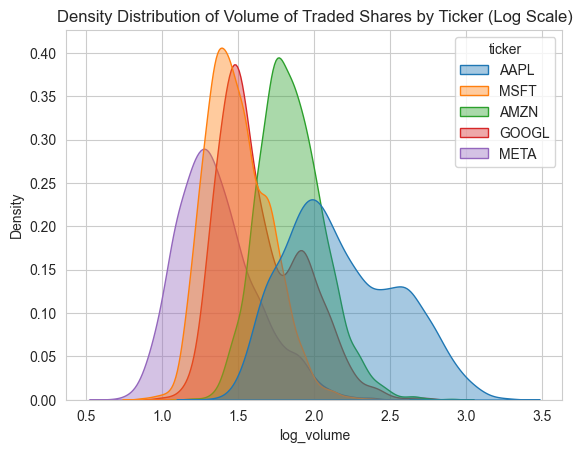

In [24]:
sns.kdeplot(data=df,x="log_volume",hue="ticker",fill=True,alpha=0.4).set_title("Density Distribution of Volume of Traded Shares by Ticker (Log Scale)")

This chart is showing us the density of shares that have been traded, so the volume of shares that have been exchanged essentially for each ticker. What really stands out here is that they're largely normally distributed apart from Apple, which has a very big right skew.

**Why this is?**

I don't know, maybe there are more tradable shares in the market compared to the other companies, so there's more liquidity, and so there's more trading that can happen?

We do have a bit of a bimodal distribution with Google as well, but Apple certainly seems to have the highest liquidity, and the others are somewhat more comparable.

Next we'll have a look to see if there's a much of a difference between the different tickers based on whether they have had more or less updates, i.e. did their price change more than zero or less than zero.

In [25]:
data = df.groupby(['ticker', 'up_day']).agg(count=('date', 'count')).reset_index()
data['pct_share'] = data['count'] / data.groupby('ticker')['count'].transform('sum')

data


,ticker,up_day,count,pct_share
0,AAPL,0,1905,0.48
1,AAPL,1,2097,0.52
2,AMZN,0,1997,0.50
3,AMZN,1,2005,0.50
4,GOOGL,0,1947,0.49
5,GOOGL,1,2055,0.51
6,META,0,1675,0.49
7,META,1,1728,0.51
8,MSFT,0,1930,0.48
9,MSFT,1,2072,0.52


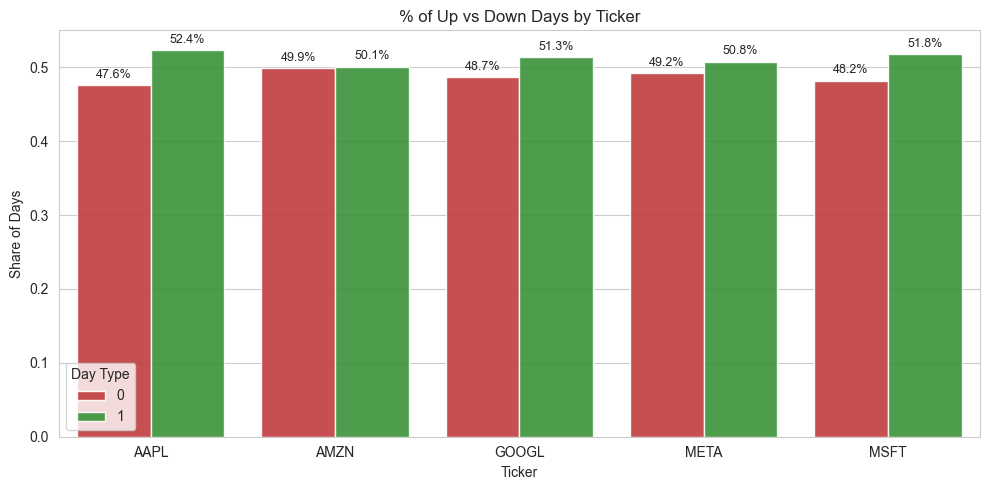

In [26]:
plt.figure(figsize=(10, 5))

palette = {
    1: '#2ca02c',
    0: '#d62728'
}

ax = sns.barplot(
    data=data,
    x='ticker',
    y='pct_share',
    hue='up_day',
    palette=palette,
    alpha=0.9,
)

# Add data labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1%}",
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=9,
            xytext=(0, 3),
            textcoords='offset points'
        )

plt.title("% of Up vs Down Days by Ticker")
plt.xlabel("Ticker")
plt.ylabel("Share of Days")
plt.legend(title="Day Type")
plt.tight_layout()
plt.show()


Apple gets the highest percent of days, where they close on a positive, followed by Microsoft and then Google. Amazon only just barely was able to have more up days than down days.

# Statistical Inference

We’ll now move on to testing for any **statistically significant relationships** within our dataset. We’ll do this by defining and evaluating two hypotheses:

**1st hypothesis**
- H0: There is **no difference in stock market returns based on the day of the week**.
- H1: There is at least one difference in stock market returns between days of the week

➡️ Our logic here is to test for any biaises in when is a good day of thw week to trade.

**2nd hypothesis**
- H0: The probability of an up day is 0.5 (the equivalent of a fair coin toss) for each ticker
- H1: The probability of an up day is greater than chance for each ticker

➡️ Our logic here is to see whether there is any underlying wisdom in the market rather than just chance

For both tests, we’ll use an **alpha level of 0.05**, as we want to reduce the risk of **Type I errors**.


## 1st Hypothesis: There is **no difference in stock market returns based on the day of the week**.

Text(0.5, 1.0, 'Overall Density Distribution of Daily % Returns by Day of Week')

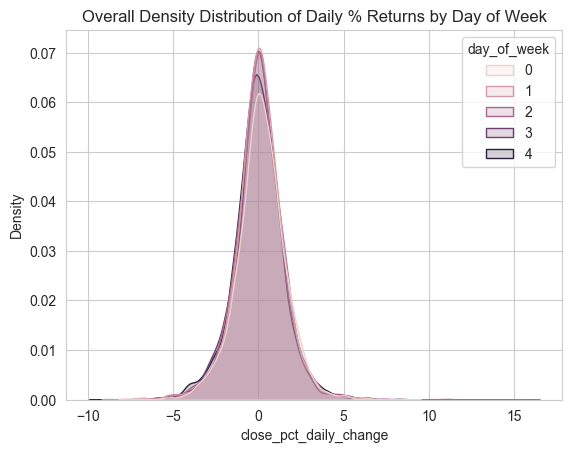

In [27]:
sns.kdeplot(data=df,x="close_pct_daily_change",hue="day_of_week",fill=True,alpha=0.2).set_title("Overall Density Distribution of Daily % Returns by Day of Week")

Our stock market returns are clearly normally distributed across all 5 days. This should make testing a lot easier!

#### Kruskal–Wallis test

It compares the ranks of sales across the 5 days of the week and tells you whether at least one group differs significantly.

It returns a :
- H statistic which tells you the average distance between the groups
- p-value which tells you how significant of a difference there is, we'll take 0.05 as our alpha

These results tell us there is a large difference between our groups but we don't know between which ones specifically. For that we'll have to do an additional test.

In [28]:
from scipy.stats import kruskal

stat, p = kruskal(df[df['day_of_week']==0]['close_pct_daily_change'],
                  df[df['day_of_week']==1]['close_pct_daily_change'],
                  df[df['day_of_week']==2]['close_pct_daily_change'],
                  df[df['day_of_week']==3]['close_pct_daily_change'],
                  df[df['day_of_week']==4]['close_pct_daily_change']
                  )

print(stat,  f'{p:.20f}')

36.404765172770375 0.00000023886955666846


### Since we observe a p-value below 0.05 (alpha), we can reject the null hypothesis and accept the alterniave hypothesis.

Somewhat surprisingly, given how much the days of the week overlap in the kernel density estimate plot, there is actually a statistically significant difference in returns across the different days.

Let's visualise these results more clearly so we can understand *where* these differences are actually occurring.


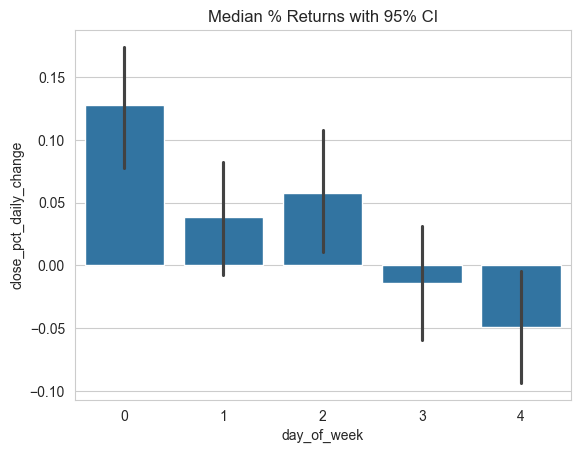

In [29]:
sns.barplot(data=df, x="day_of_week", y="close_pct_daily_change", errorbar=('ci', 95), dodge=False)
plt.title("Median % Returns with 95% CI")
plt.show()

It looks like there really isn't that much difference in what you can expect in returns for Tuesday, Wednesday, and Thursday, but it's pretty uncommon that you'll get similar returns on a Monday compared to a Friday.

Therefore, it looks like our Kruskal-Wallis test is picking up the statistically significant difference between returns based from Monday compared to Friday.

## 2nd Hypothesis: The probability of an up day is 0.5 (the equivalent of a fair coin toss) for each ticker

In [30]:
temp_data = data.copy()

In [31]:
results = []
for ticker in tickers:
    temp_data = data.copy()
    print(ticker)

    temp_data = temp_data[temp_data['ticker']==ticker]
    n_up = temp_data[temp_data['up_day']==1]['count'].sum()
    n_total = temp_data['count'].sum()

    result = binomtest(
        k=n_up,        # number of successes
        n=n_total,     # number of trials
        p=0.5,         # expected probability under H0
        alternative="two-sided"  # or "greater"
    )

    results.append({
        "ticker": ticker,
        "n_up": n_up,
        "n_total": n_total,
        "up_rate": n_up / n_total,
        "p_value": result.pvalue
    })

    print(result)

results = pd.DataFrame(results)

AAPL
BinomTestResult(k=2097, n=4002, alternative='two-sided', statistic=0.5239880059970015, pvalue=0.002529992027601903)
MSFT
BinomTestResult(k=2072, n=4002, alternative='two-sided', statistic=0.5177411294352824, pvalue=0.02581172054894537)
AMZN
BinomTestResult(k=2005, n=4002, alternative='two-sided', statistic=0.500999500249875, pvalue=0.9118940696299174)
GOOGL
BinomTestResult(k=2055, n=4002, alternative='two-sided', statistic=0.5134932533733133, pvalue=0.09074873365158413)
META
BinomTestResult(k=1728, n=3403, alternative='two-sided', statistic=0.5077872465471642, pvalue=0.37271731401004105)


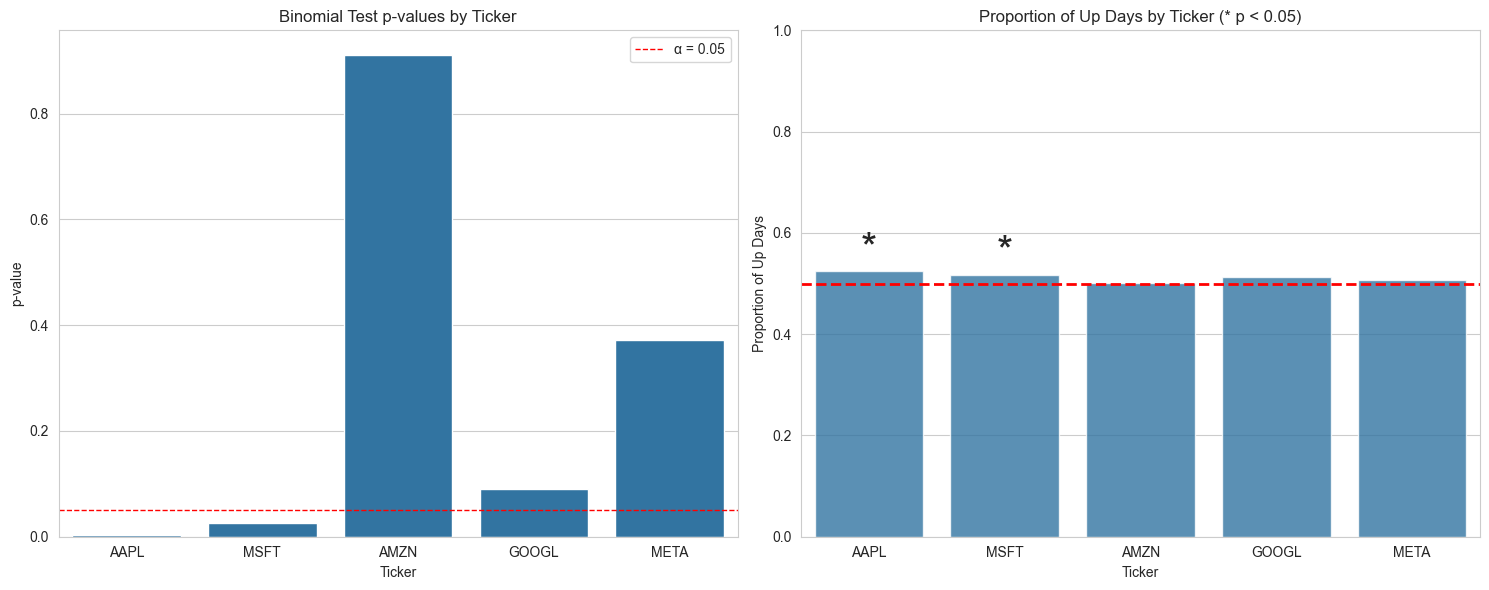

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Left Chart
sns.barplot(
    data=results,
    x="ticker",
    y="p_value",
    dodge=False,
    ax=ax[0]
)

ax[0].axhline(
    0.05,
    color="red",
    linestyle="--",
    linewidth=1,
    label="α = 0.05"
)

ax[0].set_title("Binomial Test p-values by Ticker")
ax[0].set_ylabel("p-value")
ax[0].set_xlabel("Ticker")

ax[0].legend()


# Right Chart
sns.barplot(
    data=results,
    x="ticker",
    y="up_rate",
    alpha=0.8,
    ax=ax[1]
)

ax[1].axhline(0.5, color="red", linestyle="--", linewidth=2)

for i, row in results.iterrows():
    if row["p_value"] < 0.05:
        ax[1].text(i, row["up_rate"] + 0.02, "*", ha="center", fontsize=30)

ax[1].set_ylim(0, 1)
ax[1].set_ylabel("Proportion of Up Days")
ax[1].set_xlabel("Ticker")
ax[1].set_title("Proportion of Up Days by Ticker (* p < 0.05)")


plt.tight_layout()
plt.show()


The chart on the left shows the **binomial test p-values for each ticker**, with the red line indicating our **alpha threshold of 0.05**. From this, we can see that **Apple** and **Microsoft** fall below the threshold, while the remaining tickers do not. **Amazon**, in particular, sits well above the alpha level.

On the right, we have a **bar plot** showing the **proportion of up days** for each ticker, where an up day is defined as a return greater than zero. The tickers that are **statistically significant** have been starred.

However, it’s important to interpret this in the context of our original hypothesis. Our null hypothesis stated that the **probability of an up day is 0.5 for each ticker**. Since only **two out of the five tickers** have p-values below 0.05, we **fail to reject the null hypothesis** overall.

In other words, the evidence is not strong enough to conclude that *all* tickers experience up days at a rate different from random chance.


# Time Series Forecasting

Build generic time-series model that is capable of predicting next day stock price based on previous patterns. Note: the model should be the same for all stocks. Evaluate its performance on each stock independently.

In [33]:
df.head()

,date,open,high,low,close,volume,ticker,close_pct_daily_change,vol_pct_daily_change,vol_pct_5d,day_of_month,day_of_week,week_of_year,month,up_day,log_volume
0,2010-01-04,6.40,6.43,6.37,6.42,493.73,AAPL,0.27,NaN,NaN,4,0,1,1,1,2.69
1,2010-01-05,6.44,6.47,6.40,6.43,601.90,AAPL,-0.10,0.22,NaN,5,1,1,1,0,2.78
2,2010-01-06,6.43,6.45,6.32,6.33,552.16,AAPL,-1.59,-0.08,NaN,6,2,1,1,0,2.74
3,2010-01-07,6.35,6.36,6.27,6.32,477.13,AAPL,-0.55,-0.14,NaN,7,3,1,1,0,2.68
4,2010-01-08,6.31,6.36,6.27,6.36,447.61,AAPL,0.80,-0.06,NaN,8,4,1,1,1,2.65


In [34]:
tseries_df = df.copy()
tseries_df = tseries_df[['date','close','ticker','close_pct_daily_change']]

tseries_df['log_close'] = np.log1p(tseries_df["close"])
tseries_df["close_log_price_change"] = (tseries_df.groupby("ticker")["log_close"].diff())
tseries_df["date"] = pd.to_datetime(tseries_df["date"])



In [35]:
tseries_df

,date,close,ticker,close_pct_daily_change,log_close,close_log_price_change
0,2010-01-04,6.42,AAPL,0.27,2.00,NaN
1,2010-01-05,6.43,AAPL,-0.10,2.01,0.00
2,2010-01-06,6.33,AAPL,-1.59,1.99,-0.01
3,2010-01-07,6.32,AAPL,-0.55,1.99,-0.00
4,2010-01-08,6.36,AAPL,0.80,2.00,0.01
...,...,...,...,...,...,...
19406,2025-11-21,593.77,META,0.98,6.39,0.01
19407,2025-11-24,612.55,META,2.39,6.42,0.03
19408,2025-11-25,635.70,META,1.96,6.46,0.04
19409,2025-11-26,633.09,META,-0.64,6.45,-0.00


We'll probably want to add some extra features to this dataset for any machine learning models we may want to use.

 ℹ️ After trying out an XGB regressor I found that tree models struggle to predict trends therefore we can try to predict returns instead then apply that to the price in our model

In [36]:
tseries_df["ret_lag_1"] = (tseries_df.groupby('ticker')["close_pct_daily_change"].shift(1))
tseries_df["ret_lag_5"] = (tseries_df.groupby('ticker')["close_pct_daily_change"].shift(5))
tseries_df["ret_lag_20"] = (tseries_df.groupby('ticker')["close_pct_daily_change"].shift(20))


tseries_df["ret_mean_5"] = (tseries_df.groupby("ticker")["close_pct_daily_change"].rolling(5).mean().reset_index(level=0, drop=True)
)
tseries_df["ret_mean_20"] = (tseries_df.groupby("ticker")["close_pct_daily_change"].rolling(20).mean().reset_index(level=0, drop=True)
)
tseries_df["ret_var_20"] = (tseries_df.groupby("ticker")["close_pct_daily_change"].rolling(5).std().reset_index(level=0, drop=True)
)

Text(0.5, 1.0, 'Combined Close Price all Ticker')

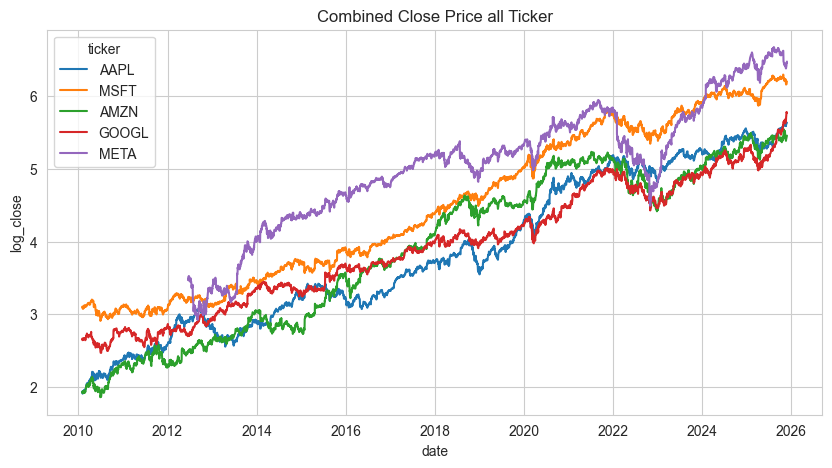

In [37]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=tseries_df.dropna(), x="date", y="log_close", hue='ticker').set_title("Combined Close Price all Ticker")

Like we saw earlier each ticker generally follows a positive linear trend with specific periods of higher variance such as 2020 and 2022.

Let's create a smoothed version to reduce noise, this could be useful for us later down the line.

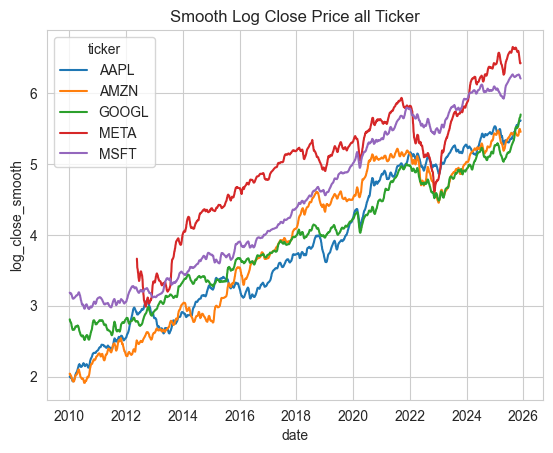

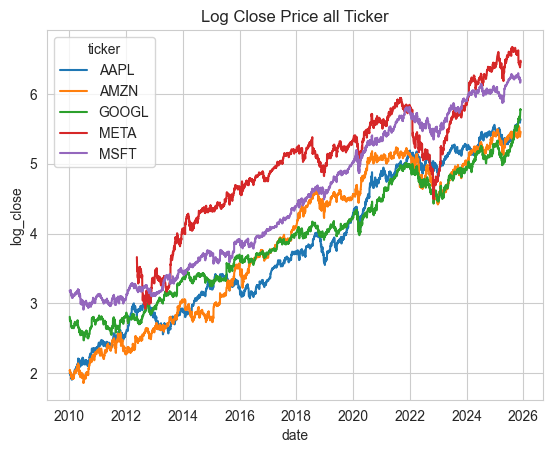

In [38]:
tseries_df = tseries_df.sort_values(["ticker", "date"])

tseries_df["log_close_smooth"] = (tseries_df.groupby("ticker")["log_close"].transform(lambda x: x.rolling(window=14, min_periods=1).mean())
)

sns.lineplot(data=tseries_df,x='date', y='log_close_smooth', hue='ticker').set_title("Smooth Log Close Price all Ticker")
plt.show()

sns.lineplot(data=tseries_df,x='date', y='log_close', hue='ticker').set_title("Log Close Price all Ticker")
plt.show()


Now let's check to see if there's any seasonality to our data.

AAPL


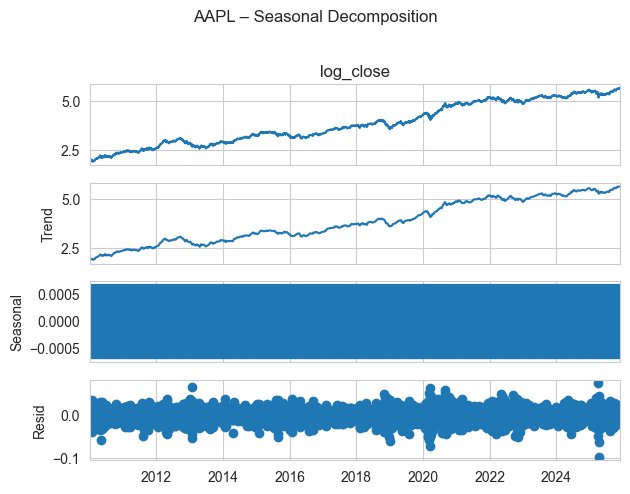

MSFT


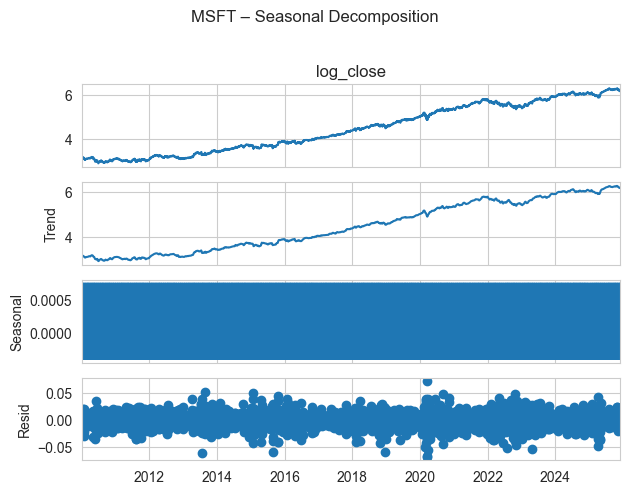

AMZN


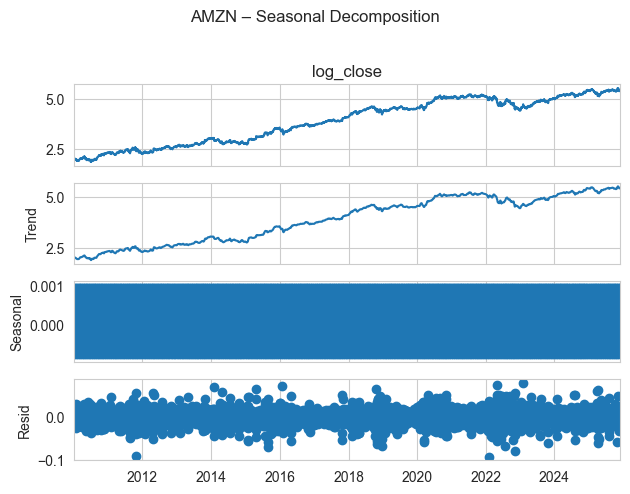

GOOGL


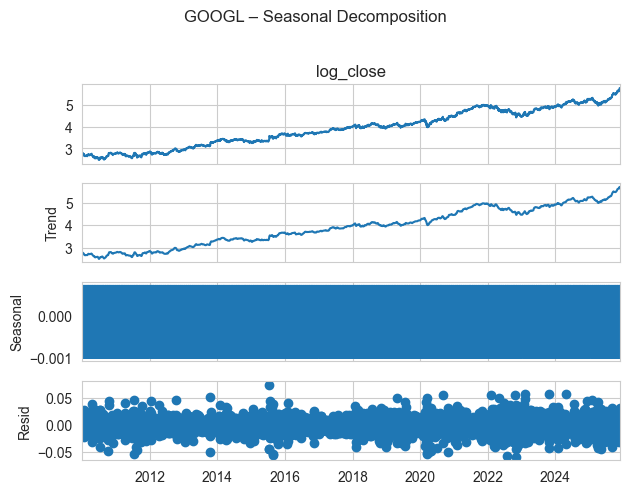

META


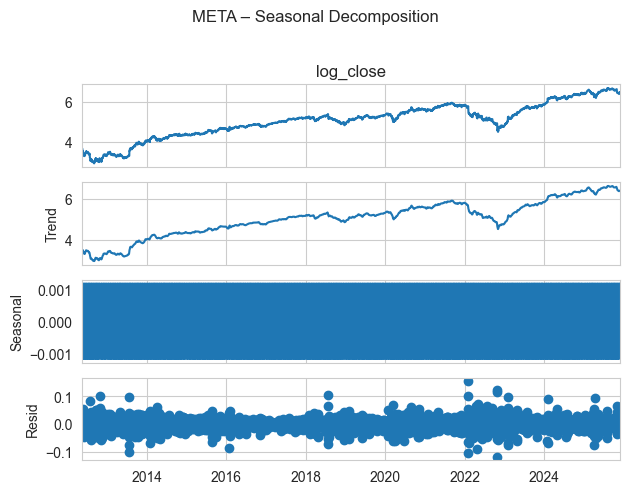

In [39]:
for ticker in tickers:
    print(ticker)

    df_t = (
        tseries_df
        .loc[tseries_df["ticker"] == ticker]
        .sort_values("date")
        .set_index("date")
    )

    decomposition = seasonal_decompose(
        df_t["log_close"].dropna(),
        model="additive",
        period=7
    )

    decomposition.plot()
    plt.suptitle(f"{ticker} – Seasonal Decomposition", y=1.02)
    plt.tight_layout()
    plt.show()


These components can be added together to reconstruct the data shown in the top panel.

The seasonal component seems to be returning noise, we'll assume this means there is no seasonal pattern as the trend is continious. The residual component shown in the bottom panel is what is left over when the seasonal and trend-cycle components have been subtracted from the data and shows what I assume are acceptable levels of variance given that it's spread over time.

### Stationarity

In order to build a good model we need to adjust our time series based on whether the data is stationary. We can define this by looking at 3 things:

- Mean of the time series is constant i.e the line is horizontal
- The standard deviation is constant i.e there's no large variance
- There's no seasonality i.e no perioidic sigma wave shape

We can already tell our data isn't stationary as the line is trending upwards with brief periods of varinace. But we can also test for it too!

In [40]:
from statsmodels.tsa.stattools import adfuller

for ticker in tickers:
    print(ticker)

    df_t = (
        tseries_df
        .loc[tseries_df["ticker"] == ticker]
        .sort_values("date")
        .set_index("date")
    )


    result = adfuller(df_t['log_close'].dropna())
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")


AAPL
ADF Statistic: -0.6152621834169746
p-value: 0.8674959720532989
MSFT
ADF Statistic: 0.37001102801401975
p-value: 0.9803381511087338
AMZN
ADF Statistic: -0.913431612089767
p-value: 0.7835170200619517
GOOGL
ADF Statistic: 0.6447839371926618
p-value: 0.988669003657596
META
ADF Statistic: -1.2082849155462063
p-value: 0.670021634649951


A p-value less than 0.05 typically suggests the data is stationary. This tells us our data is veeeeeery far from being stationary.

We'll have to use differencing to meet the conditions in order to make a sensible model.


In [41]:
tseries_df

,date,close,ticker,close_pct_daily_change,log_close,close_log_price_change,ret_lag_1,ret_lag_5,ret_lag_20,ret_mean_5,ret_mean_20,ret_var_20,log_close_smooth
0,2010-01-04,6.42,AAPL,0.27,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00
1,2010-01-05,6.43,AAPL,-0.10,2.01,0.00,0.27,NaN,NaN,NaN,NaN,NaN,2.00
2,2010-01-06,6.33,AAPL,-1.59,1.99,-0.01,-0.10,NaN,NaN,NaN,NaN,NaN,2.00
3,2010-01-07,6.32,AAPL,-0.55,1.99,-0.00,-1.59,NaN,NaN,NaN,NaN,NaN,2.00
4,2010-01-08,6.36,AAPL,0.80,2.00,0.01,-0.55,NaN,NaN,-0.24,NaN,0.91,2.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7999,2025-11-21,472.12,MSFT,-1.33,6.16,-0.01,-2.90,2.40,0.16,-1.07,-0.50,1.11,6.21
8000,2025-11-24,474.00,MSFT,-0.21,6.16,0.00,-1.33,-0.19,-0.05,-1.07,-0.51,1.11,6.21
8001,2025-11-25,476.99,MSFT,0.62,6.17,0.01,-0.21,-0.32,-1.44,-0.89,-0.41,1.33,6.20
8002,2025-11-26,485.50,MSFT,-0.17,6.19,0.02,0.62,-0.61,-0.62,-0.80,-0.39,1.36,6.20


In [42]:
tseries_df[tseries_df['ticker'] == 'MSFT']

,date,close,ticker,close_pct_daily_change,log_close,close_log_price_change,ret_lag_1,ret_lag_5,ret_lag_20,ret_mean_5,ret_mean_20,ret_var_20,log_close_smooth
4002,2010-01-04,23.13,MSFT,1.08,3.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.18
4003,2010-01-05,23.14,MSFT,0.36,3.18,0.00,1.08,NaN,NaN,NaN,NaN,NaN,3.18
4004,2010-01-06,23.00,MSFT,-0.36,3.18,-0.01,0.36,NaN,NaN,NaN,NaN,NaN,3.18
4005,2010-01-07,22.76,MSFT,-0.59,3.17,-0.01,-0.36,NaN,NaN,NaN,NaN,NaN,3.18
4006,2010-01-08,22.91,MSFT,1.25,3.17,0.01,-0.59,NaN,NaN,0.35,NaN,0.83,3.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7999,2025-11-21,472.12,MSFT,-1.33,6.16,-0.01,-2.90,2.40,0.16,-1.07,-0.50,1.11,6.21
8000,2025-11-24,474.00,MSFT,-0.21,6.16,0.00,-1.33,-0.19,-0.05,-1.07,-0.51,1.11,6.21
8001,2025-11-25,476.99,MSFT,0.62,6.17,0.01,-0.21,-0.32,-1.44,-0.89,-0.41,1.33,6.20
8002,2025-11-26,485.50,MSFT,-0.17,6.19,0.02,0.62,-0.61,-0.62,-0.80,-0.39,1.36,6.20


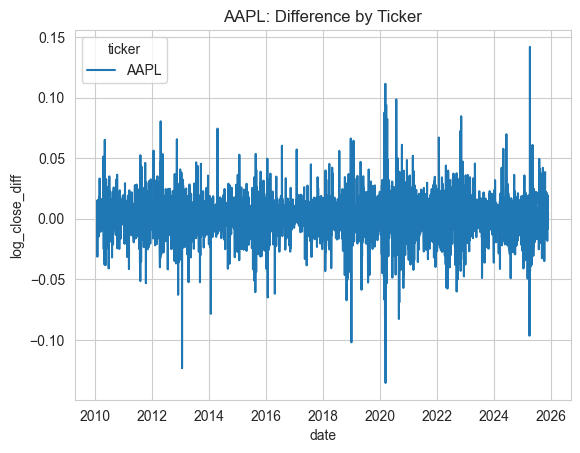

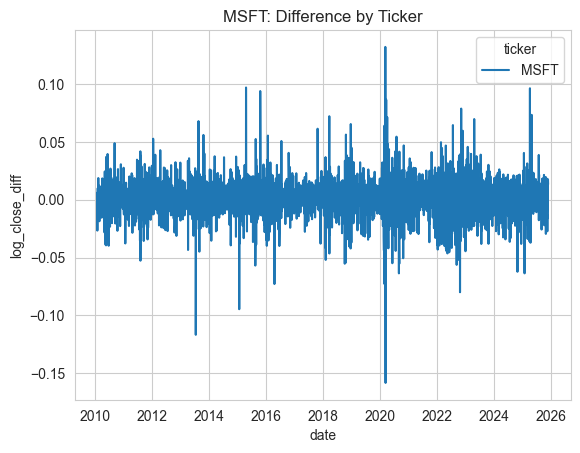

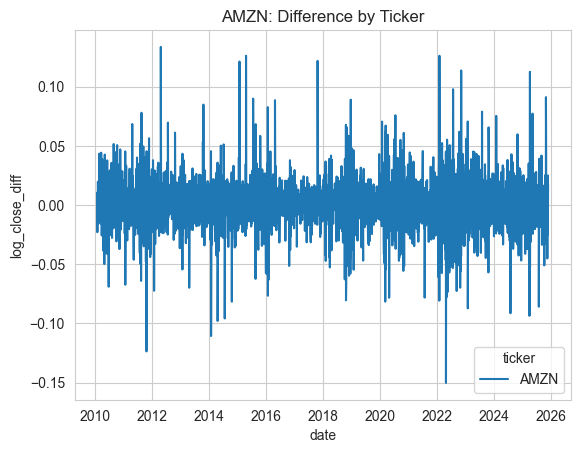

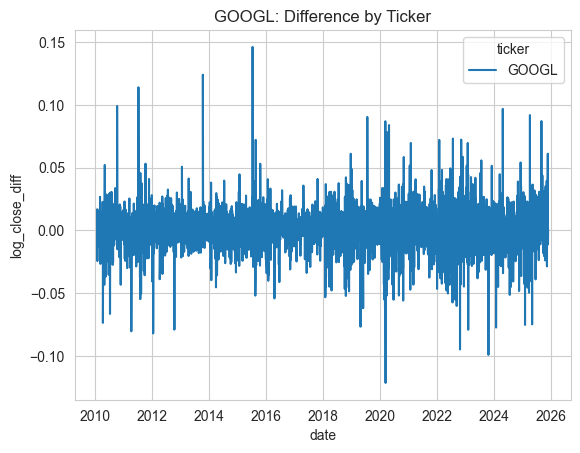

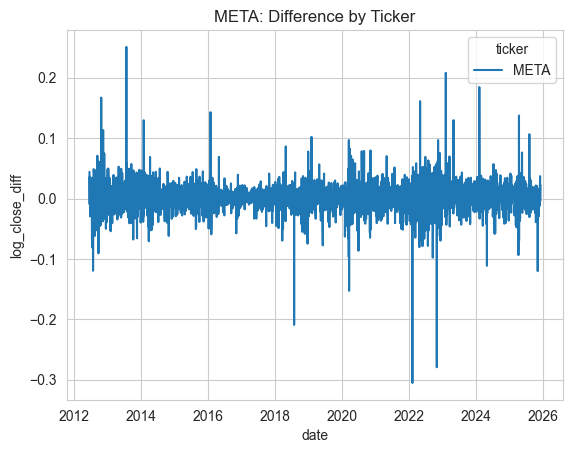

In [43]:
tseries_df = tseries_df.sort_values(["ticker", "date"])

tseries_df["log_close_diff"] = (tseries_df.groupby("ticker")["log_close"].diff())

for ticker in tickers:
    df_t = (
        tseries_df
        .loc[tseries_df["ticker"] == ticker]
        .sort_values("date")
        .set_index("date")
    )

    sns.lineplot(data=df_t.dropna(), x='date', y='log_close_diff', hue='ticker').set_title(f"{ticker}: Difference by Ticker")

    plt.show()


We definetly have some variance in our data but we'll assume this isn't enough to negate our stationarity.

## Models

We'll apply a few models to try and get to the best predictor but we'll start off by creating a baseline. The best measure for a baseline would be a naive model which simply assumes the latest price from the previous date.



**Baseline Model**

In [44]:
tseries_df["baseline_log_forecast"] = tseries_df.groupby('ticker')['log_close'].shift(1)

forecast = []

for ticker in tickers:
    temp_df = tseries_df[tseries_df["ticker"] == ticker]

    forecast.append({
        "ticker": ticker,
        "price": round(np.expm1(temp_df["baseline_log_forecast"].iloc[-1]), 2),
        "model": "Baseline (t-1)"
    })

baseline_forecasts = pd.DataFrame(forecast)

In [45]:
tseries_df.head()

,date,close,ticker,close_pct_daily_change,log_close,close_log_price_change,ret_lag_1,ret_lag_5,ret_lag_20,ret_mean_5,ret_mean_20,ret_var_20,log_close_smooth,log_close_diff,baseline_log_forecast
0,2010-01-04,6.42,AAPL,0.27,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,NaN,NaN
1,2010-01-05,6.43,AAPL,-0.10,2.01,0.00,0.27,NaN,NaN,NaN,NaN,NaN,2.00,0.00,2.00
2,2010-01-06,6.33,AAPL,-1.59,1.99,-0.01,-0.10,NaN,NaN,NaN,NaN,NaN,2.00,-0.01,2.01
3,2010-01-07,6.32,AAPL,-0.55,1.99,-0.00,-1.59,NaN,NaN,NaN,NaN,NaN,2.00,-0.00,1.99
4,2010-01-08,6.36,AAPL,0.80,2.00,0.01,-0.55,NaN,NaN,-0.24,NaN,0.91,2.00,0.01,1.99


**ARIMA**

We can check the best ARIMA paramters based on autocorrelation. Given that our time series data is so long and in a linear trend I expect the most recent datapoints to be the most correlated


In [46]:

for ticker in tickers:
    temp_df = tseries_df[tseries_df["ticker"] == ticker]
    print(f"\n{ticker} ")
    # Autocorrelation at different lags
    for lag in [1, 2, 7, 14, 30, 60, 120]:
        print(f"Lag {lag} autocorrelation: {round(temp_df["log_close"].autocorr(lag=lag), 3)} "
              f"Smoothed Lag {lag} autocorrelation: ",round(temp_df["log_close_smooth"].autocorr(lag=lag), 3))



AAPL 
Lag 1 autocorrelation: 1.0 Smoothed Lag 1 autocorrelation:  1.0
Lag 2 autocorrelation: 1.0 Smoothed Lag 2 autocorrelation:  1.0
Lag 7 autocorrelation: 0.999 Smoothed Lag 7 autocorrelation:  1.0
Lag 14 autocorrelation: 0.998 Smoothed Lag 14 autocorrelation:  0.999
Lag 30 autocorrelation: 0.996 Smoothed Lag 30 autocorrelation:  0.997
Lag 60 autocorrelation: 0.992 Smoothed Lag 60 autocorrelation:  0.993
Lag 120 autocorrelation: 0.987 Smoothed Lag 120 autocorrelation:  0.987

MSFT 
Lag 1 autocorrelation: 1.0 Smoothed Lag 1 autocorrelation:  1.0
Lag 2 autocorrelation: 1.0 Smoothed Lag 2 autocorrelation:  1.0
Lag 7 autocorrelation: 0.999 Smoothed Lag 7 autocorrelation:  1.0
Lag 14 autocorrelation: 0.999 Smoothed Lag 14 autocorrelation:  0.999
Lag 30 autocorrelation: 0.998 Smoothed Lag 30 autocorrelation:  0.998
Lag 60 autocorrelation: 0.996 Smoothed Lag 60 autocorrelation:  0.997
Lag 120 autocorrelation: 0.993 Smoothed Lag 120 autocorrelation:  0.994

AMZN 
Lag 1 autocorrelation: 1.0 

In [47]:
from statsmodels.tsa.arima.model import ARIMA

# Always sort for time series
tseries_df = tseries_df.sort_values(["ticker", "date"])

forecasts = []
for ticker in tickers:
    temp_df = tseries_df[tseries_df["ticker"] == ticker]

    model = ARIMA(
        temp_df["log_close"],
        order=(2, 1, 2)
    )
    arima_model_fit = model.fit()

    # fittedvalues index aligns with temp_df
    tseries_df.loc[temp_df.index, "arima_log_close"] = (arima_model_fit.fittedvalues)

    arima_forecast = arima_model_fit.forecast(steps=1)
    second_value = round(np.expm1(arima_forecast.iloc[0]),2)

    forecasts.append(
    {
        'ticker': ticker,
        'price': second_value,
        'model': 'ARIMA'

    })

arima_forecasts = pd.DataFrame(forecasts)



In [48]:
tseries_df.tail()

,date,close,ticker,close_pct_daily_change,log_close,close_log_price_change,ret_lag_1,ret_lag_5,ret_lag_20,ret_mean_5,ret_mean_20,ret_var_20,log_close_smooth,log_close_diff,baseline_log_forecast,arima_log_close
7999,2025-11-21,472.12,MSFT,-1.33,6.16,-0.01,-2.90,2.40,0.16,-1.07,-0.50,1.11,6.21,-0.01,6.17,6.17
8000,2025-11-24,474.00,MSFT,-0.21,6.16,0.00,-1.33,-0.19,-0.05,-1.07,-0.51,1.11,6.21,0.00,6.16,6.16
8001,2025-11-25,476.99,MSFT,0.62,6.17,0.01,-0.21,-0.32,-1.44,-0.89,-0.41,1.33,6.20,0.01,6.16,6.16
8002,2025-11-26,485.50,MSFT,-0.17,6.19,0.02,0.62,-0.61,-0.62,-0.80,-0.39,1.36,6.20,0.02,6.17,6.17
8003,2025-11-28,492.01,MSFT,0.90,6.20,0.01,-0.17,-2.90,-0.89,-0.04,-0.30,0.87,6.20,0.01,6.19,6.19


**Machine Learning Model**

In [49]:
tseries_df.isna().sum()

date                        0
close                       0
ticker                      0
close_pct_daily_change      0
log_close                   0
close_log_price_change      5
ret_lag_1                   5
ret_lag_5                  25
ret_lag_20                100
ret_mean_5                 20
ret_mean_20                95
ret_var_20                 20
log_close_smooth            0
log_close_diff              5
baseline_log_forecast       5
arima_log_close             0
dtype: int64

In [50]:
features = [
    "ret_lag_1", "ret_lag_5", "ret_lag_20",
    "ret_mean_5", "ret_mean_20", "ret_var_20"
]

forecasts = []
for ticker in tickers:
    temp_df = (
        tseries_df[tseries_df["ticker"] == ticker]
        .dropna(subset=features + ["close_log_price_change"])
    )

    X = temp_df[features]
    y = temp_df["close_log_price_change"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        objective="reg:squarederror",
        random_state=42
    )

    xgb_model.fit(X_train, y_train)

    preds = xgb_model.predict(X_test)

    # Write predictions back aligned by index
    tseries_df.loc[X_test.index, "xgb_log_return_pred"] = preds


    tseries_df["xgb_log_price"] = (tseries_df.groupby("ticker")["log_close"].shift(1) + tseries_df["xgb_log_return_pred"])

    # --- Next day forecast ---
    latest_X = temp_df[features].iloc[[-1]]
    next_day_log_return = xgb_model.predict(latest_X)[0]

    last_price = tseries_df.loc[temp_df.index[-1], "xgb_log_price"]
    next_day_price = last_price * np.exp(next_day_log_return)

    forecasts.append({
        "ticker": ticker,
        "price": np.exp(next_day_price),
        "model": 'XGB'
    })


    xgb_forecasts = pd.DataFrame(forecasts)




In [51]:
all_forecasts = pd.concat(
    [baseline_forecasts, arima_forecasts, xgb_forecasts],
    axis=0,
    ignore_index=True
)

In [52]:
tseries_df["xgb_log_price"] = (tseries_df.groupby("ticker")["log_close"].shift(1) + tseries_df["xgb_log_return_pred"])

In [53]:
tseries_df.isna().sum()

date                          0
close                         0
ticker                        0
close_pct_daily_change        0
log_close                     0
close_log_price_change        5
ret_lag_1                     5
ret_lag_5                    25
ret_lag_20                  100
ret_mean_5                   20
ret_mean_20                  95
ret_var_20                   20
log_close_smooth              0
log_close_diff                5
baseline_log_forecast         5
arima_log_close               0
xgb_log_return_pred       15546
xgb_log_price             15546
dtype: int64

In [54]:
for pred in ['baseline_log_forecast','arima_log_close','xgb_log_price']:
    print(f"Model - {pred}")
    hf.time_series_model_score(tseries_df['log_close'], tseries_df[pred])

Model - baseline_log_forecast
Mean Absolute Error: 0.012858478241767392 
Mean Squared Error: 0.0003621763698259979 
Mean Absolute Percentage Error: 0.3237887367045939 
Forecast Bias (+ Overpredict - Underpredit): -0.019396796478521713 

Model - arima_log_close
Mean Absolute Error: 0.013559646564394606 
Mean Squared Error: 0.0024019293741871263 
Mean Absolute Percentage Error: 0.3494691690833432 
Forecast Bias (+ Overpredict - Underpredit): -0.03729965504247815 

Model - xgb_log_price
Mean Absolute Error: 0.012836477297957708 
Mean Squared Error: 0.00034103691821216854 
Mean Absolute Percentage Error: 0.23937607687903278 
Forecast Bias (+ Overpredict - Underpredit): -0.0008743625894257905 



In [55]:
tseries_df['arima_close_price'] = np.expm1(tseries_df['arima_log_close'])
tseries_df['baseline_price_forecast'] = np.expm1(tseries_df['baseline_log_forecast'])
tseries_df['xgb_price'] = np.expm1(tseries_df['xgb_log_price'])

In [56]:
tseries_df.tail()

,date,close,ticker,close_pct_daily_change,log_close,close_log_price_change,ret_lag_1,ret_lag_5,ret_lag_20,ret_mean_5,ret_mean_20,ret_var_20,log_close_smooth,log_close_diff,baseline_log_forecast,arima_log_close,xgb_log_return_pred,xgb_log_price,arima_close_price,baseline_price_forecast,xgb_price
7999,2025-11-21,472.12,MSFT,-1.33,6.16,-0.01,-2.90,2.40,0.16,-1.07,-0.50,1.11,6.21,-0.01,6.17,6.17,-0.00,6.17,479.53,478.43,476.06
8000,2025-11-24,474.00,MSFT,-0.21,6.16,0.00,-1.33,-0.19,-0.05,-1.07,-0.51,1.11,6.21,0.00,6.16,6.16,-0.01,6.15,473.06,472.12,467.30
8001,2025-11-25,476.99,MSFT,0.62,6.17,0.01,-0.21,-0.32,-1.44,-0.89,-0.41,1.33,6.20,0.01,6.16,6.16,-0.01,6.15,474.20,474.00,468.19
8002,2025-11-26,485.50,MSFT,-0.17,6.19,0.02,0.62,-0.61,-0.62,-0.80,-0.39,1.36,6.20,0.02,6.17,6.17,-0.01,6.16,477.02,476.99,470.69
8003,2025-11-28,492.01,MSFT,0.90,6.20,0.01,-0.17,-2.90,-0.89,-0.04,-0.30,0.87,6.20,0.01,6.19,6.19,-0.00,6.19,484.79,485.50,485.39


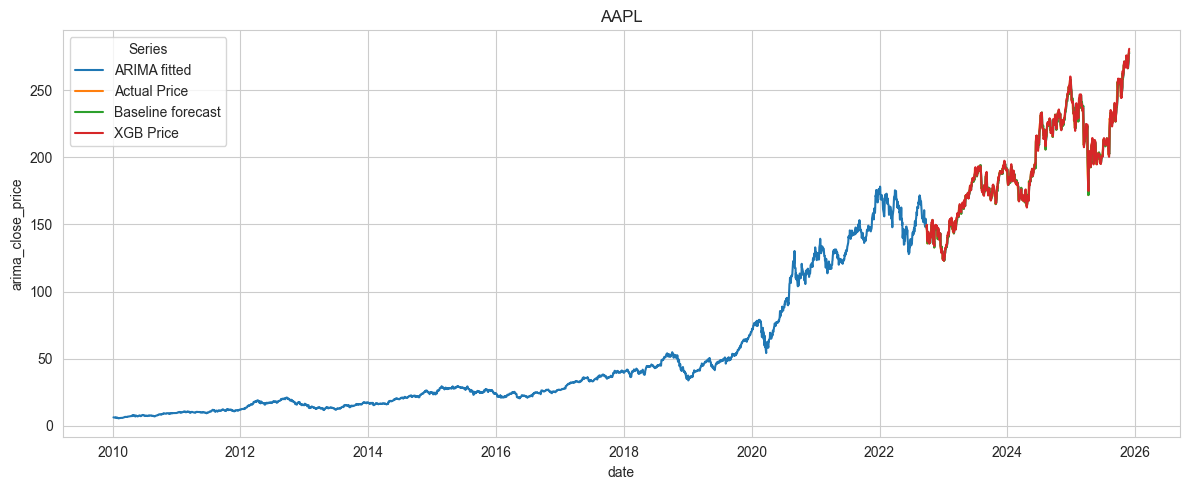

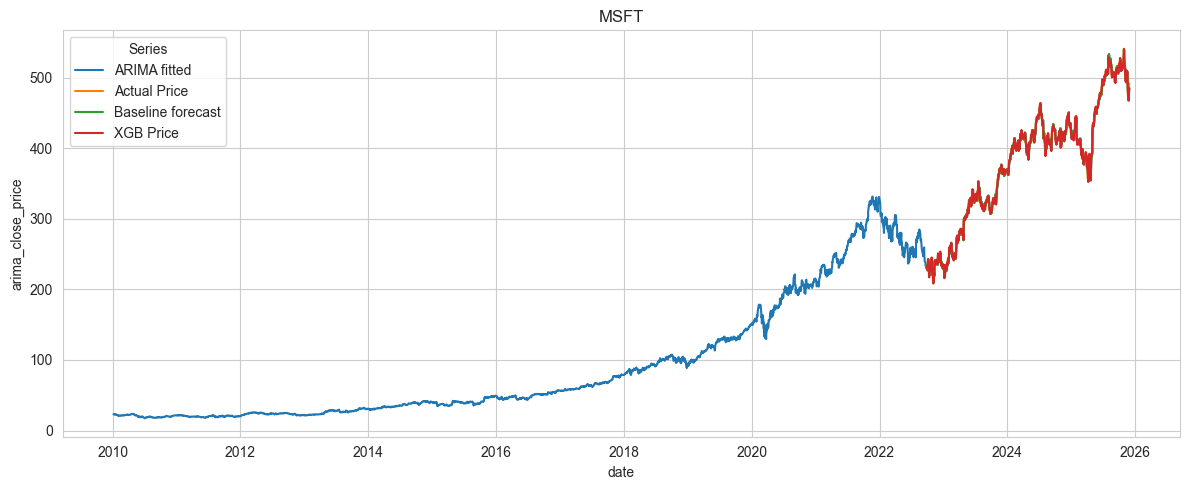

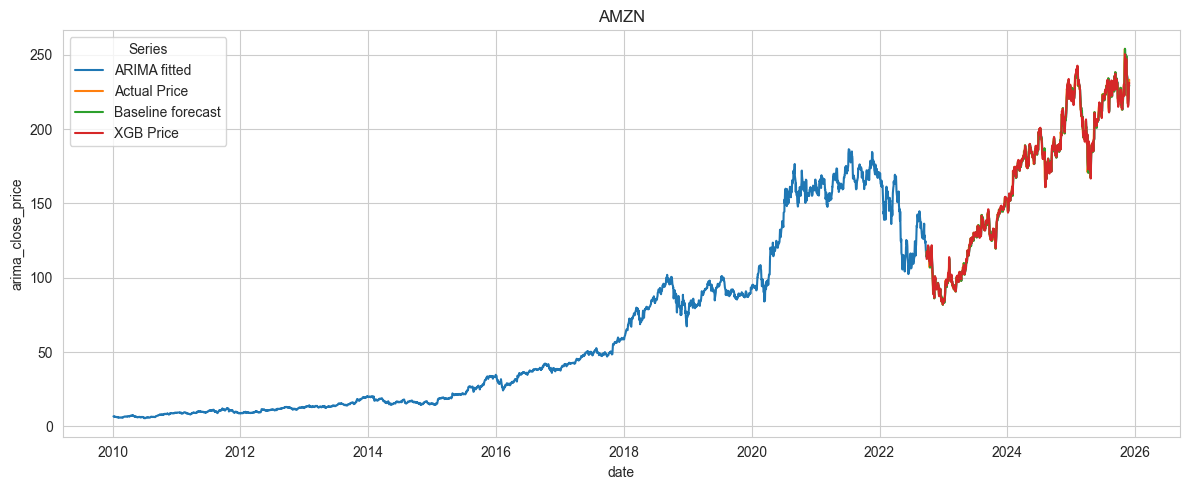

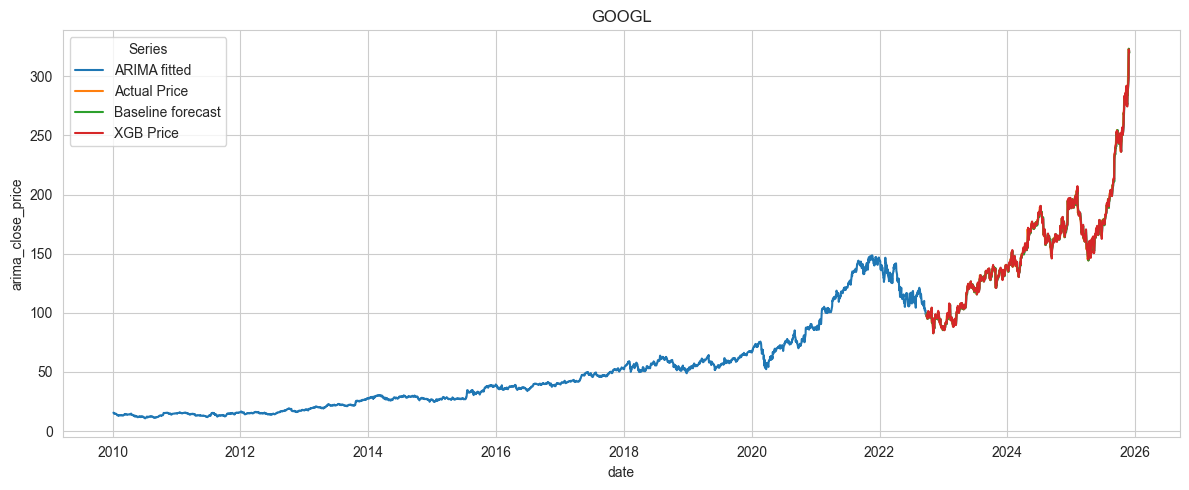

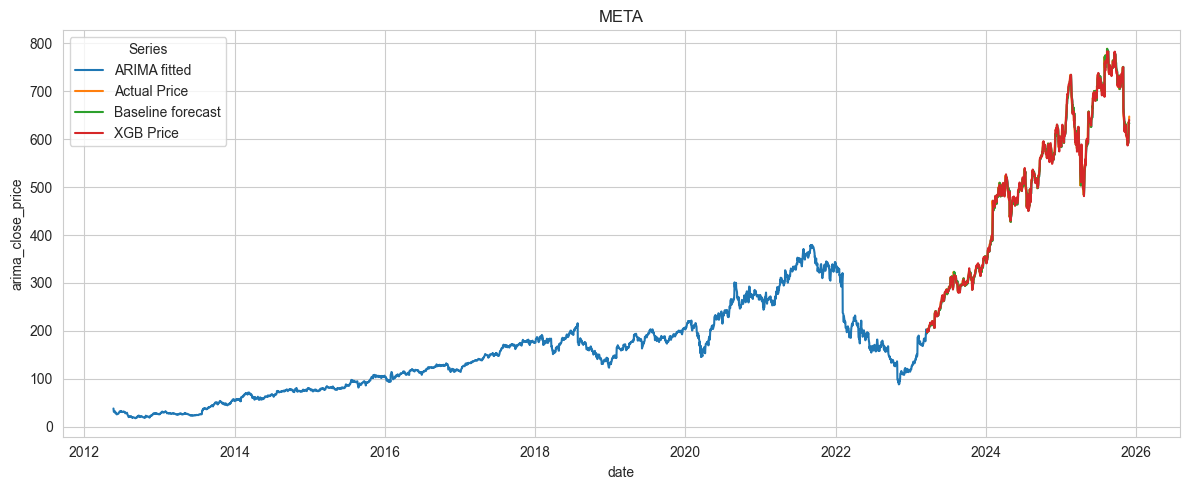

In [57]:

for ticker in tickers:
    temp_df = tseries_df[tseries_df["ticker"] == ticker]
    plt.figure(figsize=(12, 5))

    sns.lineplot(
        data=temp_df[temp_df['arima_close_price'] > 0],
        x="date",
        y="arima_close_price",
        label="ARIMA fitted"
    )

    sns.lineplot(
        data=temp_df.dropna(),
        x="date",
        y="close",
        label="Actual Price"
    )

    sns.lineplot(
        data=temp_df.dropna(),
        x="date",
        y="baseline_price_forecast",
        label="Baseline forecast"
    )

    sns.lineplot(
        data=temp_df.dropna(),
        x="date",
        y="xgb_price",
        label="XGB Price"
    ).set_title(f"{ticker}")


    plt.legend(title="Series")
    plt.tight_layout()
    plt.show()


In [58]:
tseries_df.head()

,date,close,ticker,close_pct_daily_change,log_close,close_log_price_change,ret_lag_1,ret_lag_5,ret_lag_20,ret_mean_5,ret_mean_20,ret_var_20,log_close_smooth,log_close_diff,baseline_log_forecast,arima_log_close,xgb_log_return_pred,xgb_log_price,arima_close_price,baseline_price_forecast,xgb_price
0,2010-01-04,6.42,AAPL,0.27,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN
1,2010-01-05,6.43,AAPL,-0.10,2.01,0.00,0.27,NaN,NaN,NaN,NaN,NaN,2.00,0.00,2.00,2.00,NaN,NaN,6.42,6.42,NaN
2,2010-01-06,6.33,AAPL,-1.59,1.99,-0.01,-0.10,NaN,NaN,NaN,NaN,NaN,2.00,-0.01,2.01,2.01,NaN,NaN,6.43,6.43,NaN
3,2010-01-07,6.32,AAPL,-0.55,1.99,-0.00,-1.59,NaN,NaN,NaN,NaN,NaN,2.00,-0.00,1.99,1.99,NaN,NaN,6.33,6.33,NaN
4,2010-01-08,6.36,AAPL,0.80,2.00,0.01,-0.55,NaN,NaN,-0.24,NaN,0.91,2.00,0.01,1.99,1.99,NaN,NaN,6.32,6.32,NaN


In [59]:
tickers

['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META']

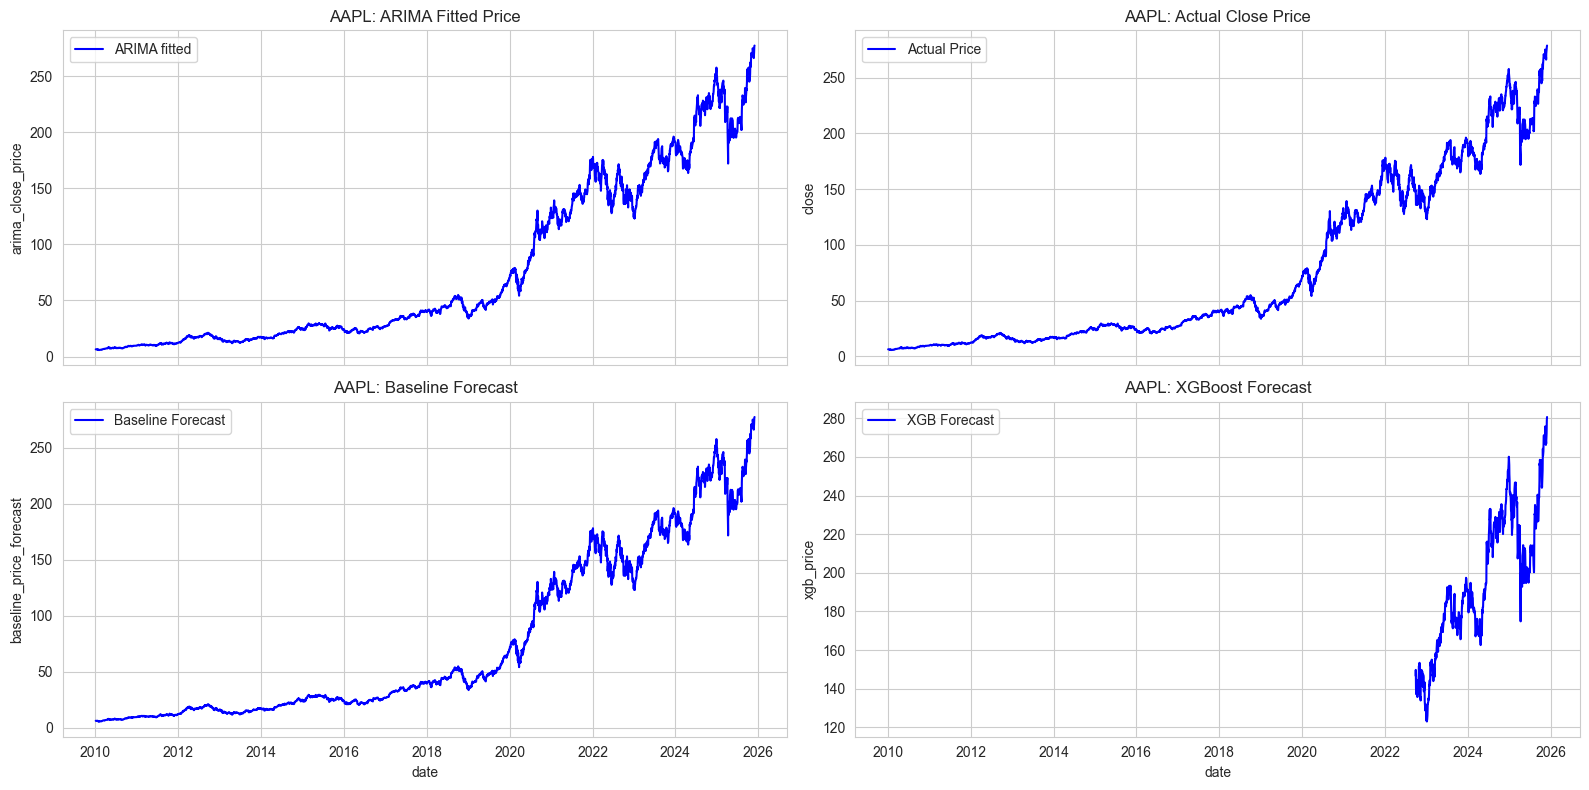

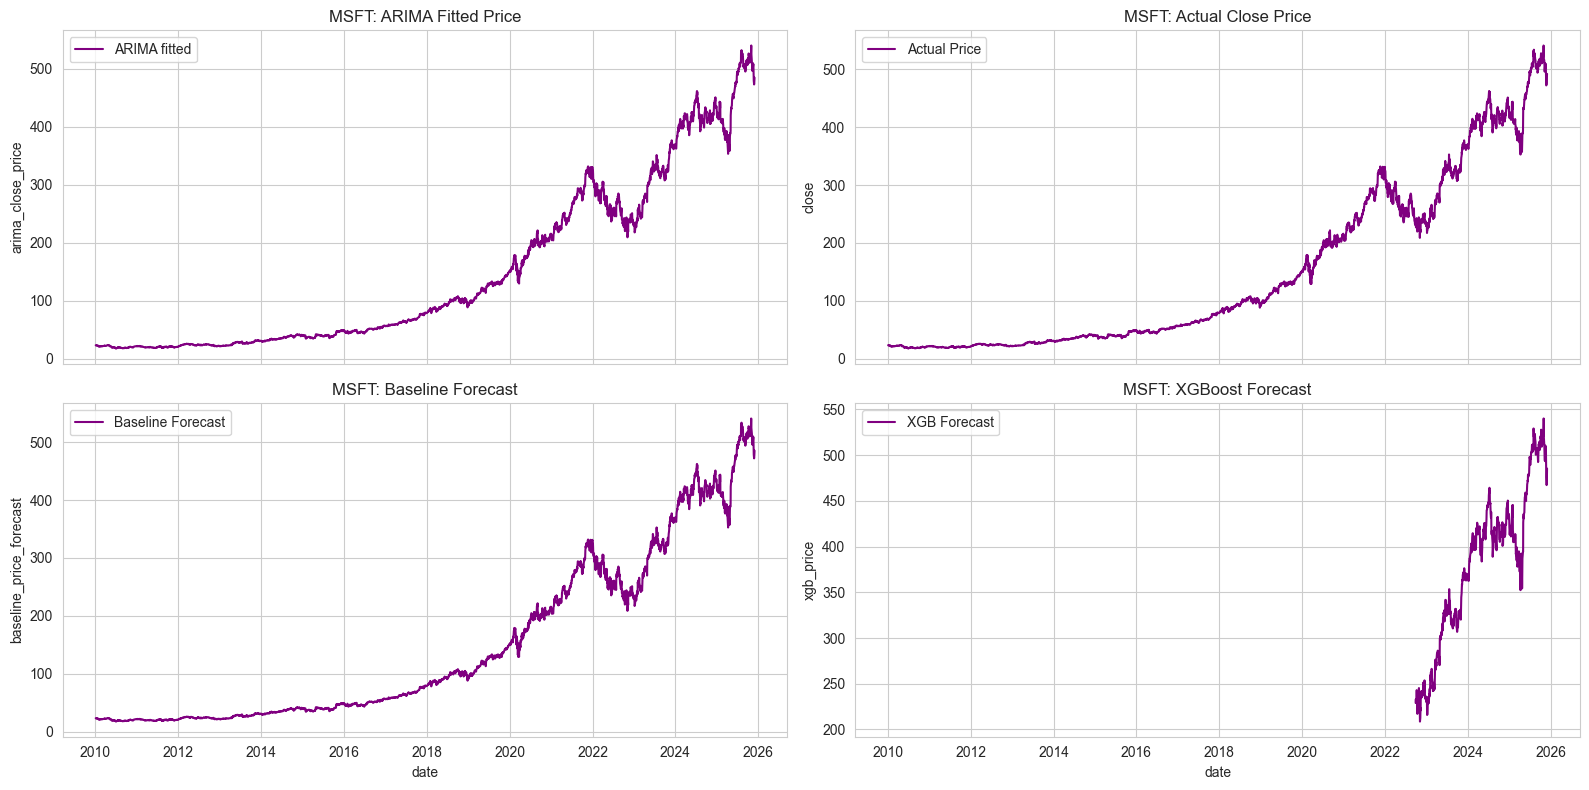

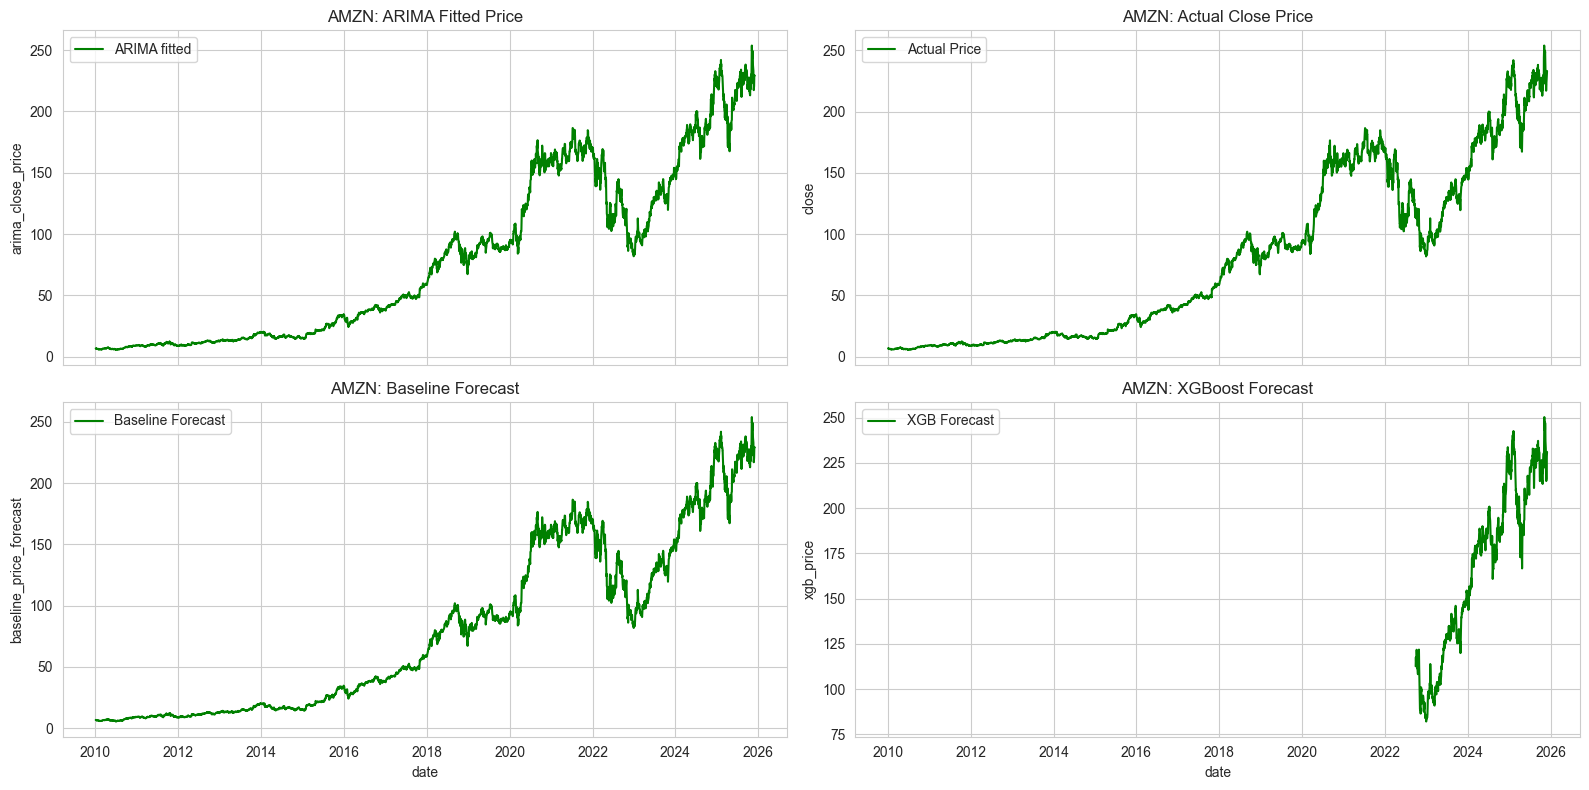

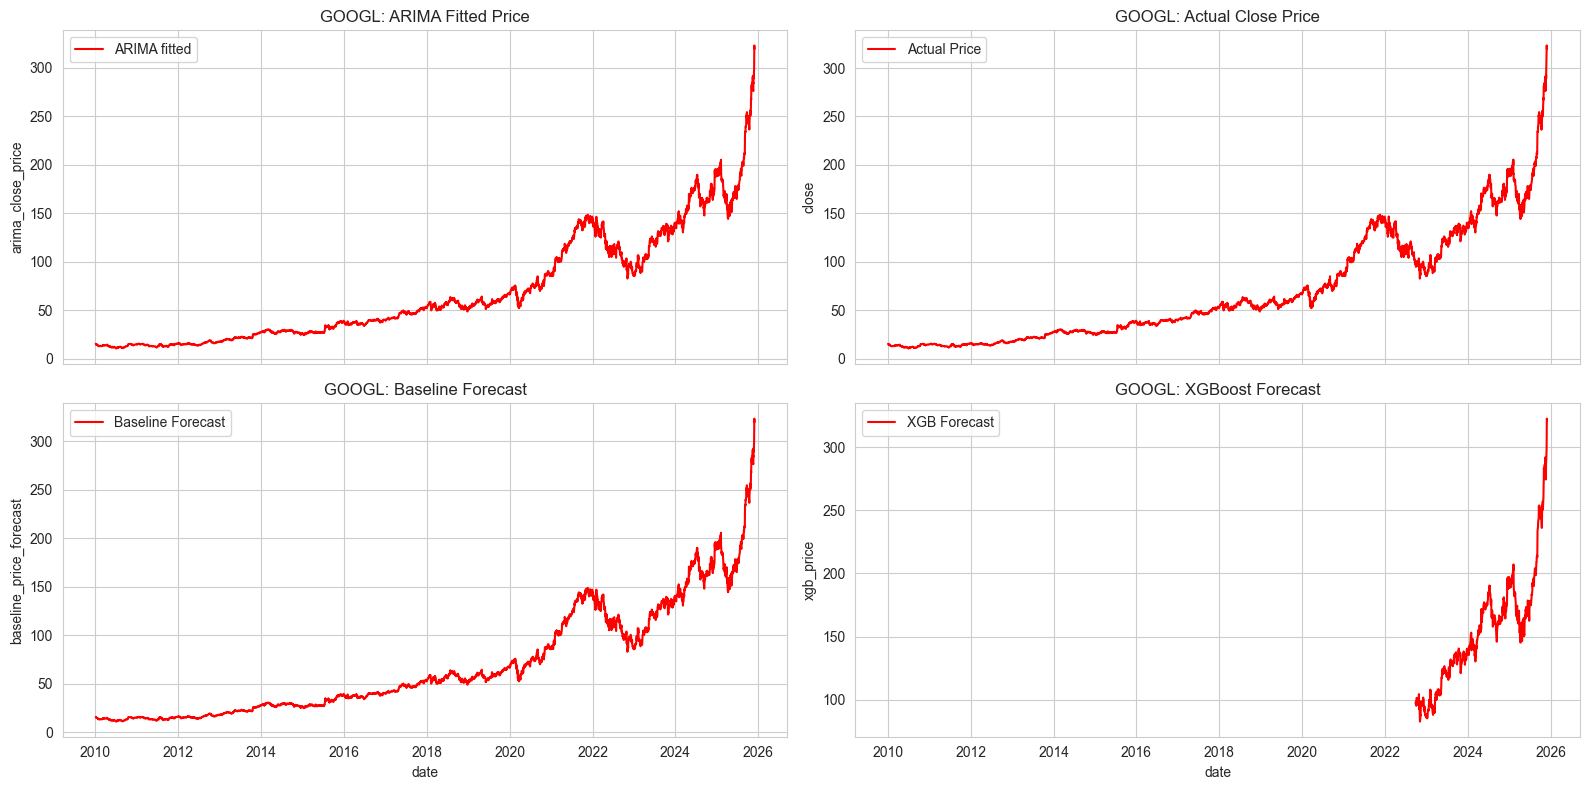

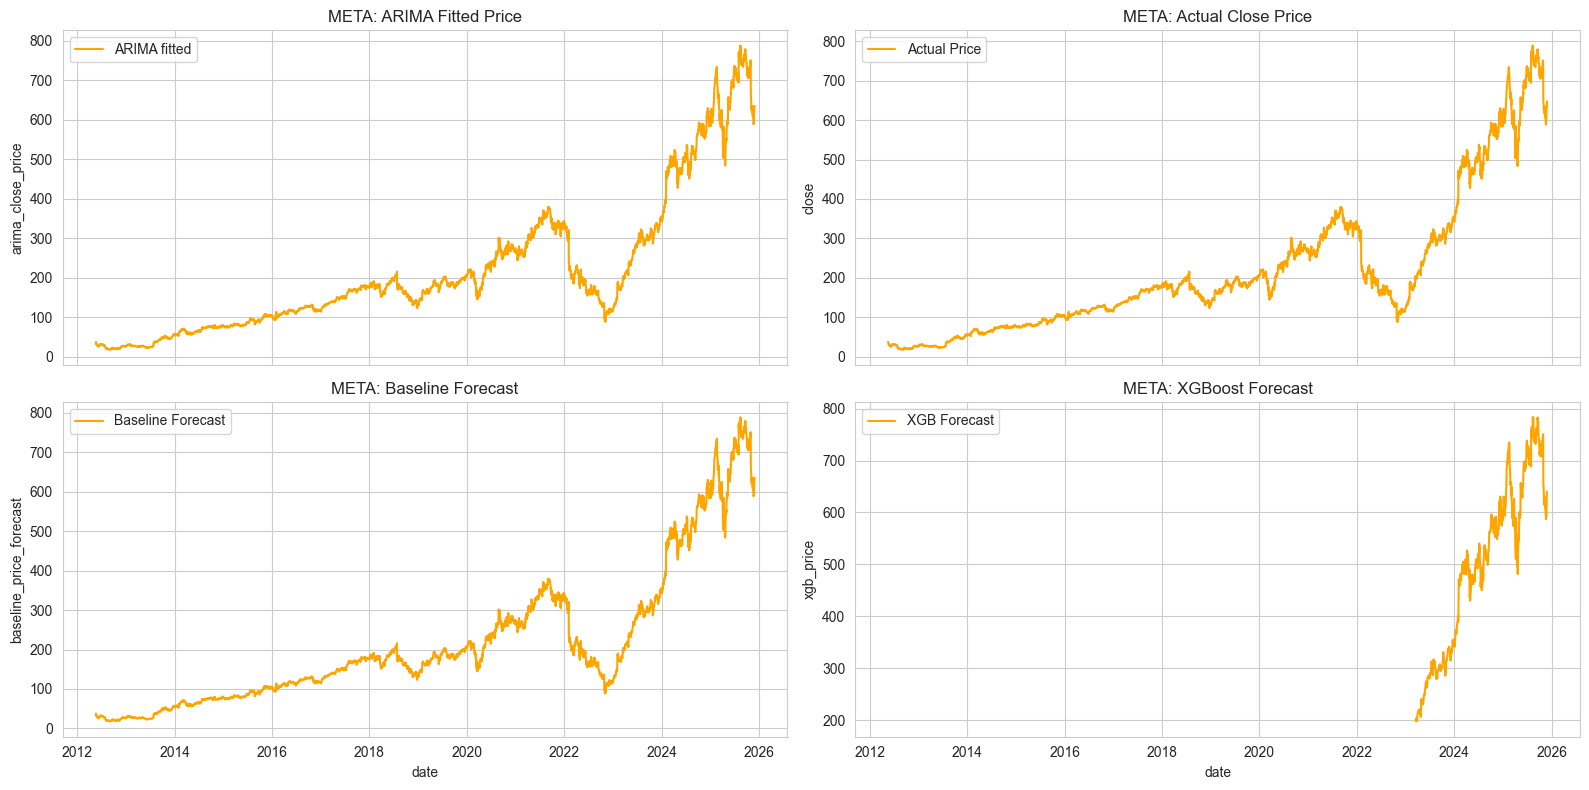

In [60]:
for ticker in tickers:
    fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)

    temp_df = tseries_df[tseries_df["ticker"] == ticker]
    colour = None
    if ticker == 'AAPL':
        colour = 'blue'
    elif ticker == 'GOOGL':
        colour = 'red'
    elif ticker == 'AMZN':
        colour = 'green'
    elif ticker == 'MSFT':
        colour = 'purple'
    elif ticker == 'META':
        colour = 'orange'

    # ARIMA
    sns.lineplot(
        data=temp_df[temp_df['arima_close_price'] > 0],
        x="date",
        y="arima_close_price",
        ax=axes[0, 0],
        label="ARIMA fitted",
        color=colour
    )
    axes[0, 0].set_title(f"{ticker}: ARIMA Fitted Price")
    axes[0, 0].legend()

    # Actual
    sns.lineplot(
        data=temp_df[temp_df["close"].notna()],
        x="date",
        y="close",
        ax=axes[0, 1],
        label="Actual Price",
        color=colour
    )
    axes[0, 1].set_title(f"{ticker}: Actual Close Price")
    axes[0, 1].legend()

    # Baseline
    sns.lineplot(
        data=temp_df[temp_df["baseline_price_forecast"].notna()],
        x="date",
        y="baseline_price_forecast",
        ax=axes[1, 0],
        label="Baseline Forecast",
        color=colour
    )
    axes[1, 0].set_title(f"{ticker}: Baseline Forecast")
    axes[1, 0].legend()

    # XGB
    sns.lineplot(
        data=temp_df[temp_df["xgb_price"].notna()],
        x="date",
        y="xgb_price",
        ax=axes[1, 1],
        label="XGB Forecast",
        color=colour
    )
    axes[1, 1].set_title(f"{ticker}: XGBoost Forecast")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


It seems like each model follows pretty closely to our existing line. Let's forecast into the future and then get a prediction for each of our ticker's next day expected stock price

# Next Day Forecasts

As the XGB Regressor gave us the lowest error and lowest biais for our ticker data we'll use this as our main predictor:

In [61]:
all_forecasts[all_forecasts['model']=='XGB']

,ticker,price,model
10,AAPL,300.17,XGB
11,MSFT,485.74,XGB
12,AMZN,243.13,XGB
13,GOOGL,330.51,XGB
14,META,689.43,XGB


### Forecast Comparison

<Axes: xlabel='ticker', ylabel='price'>

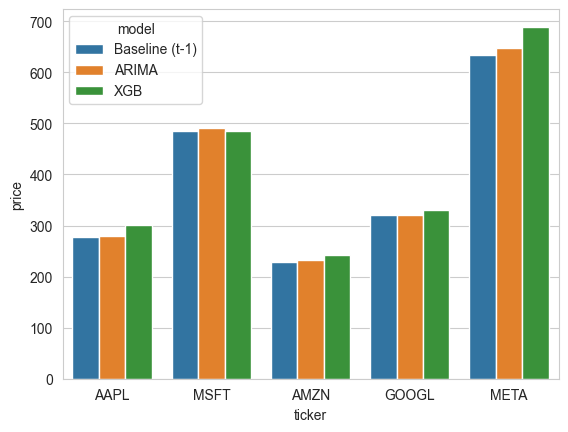

In [62]:
sns.barplot(data=all_forecasts,x='ticker',y='price',hue='model')

# Survival Analysis

Using survival analysis methods, train models that are capable of predicting time to event (in this case event is ≥5% daily increase in stock price). Note: the model should be the same for all stocks. Evaluate its performance on each stock independently.

In [63]:
# Connect (in-memory or to a local DB file)
pd.set_option("display.max_rows", None)

survival_df = df.copy()


con = duckdb.connect()

query = """

WITH events AS (
    SELECT
        ticker,
        MIN(date) AS first_date,
        MIN(CASE WHEN ABS(close_pct_daily_change) > 5 THEN date END) AS first_event,

    FROM survival_df
    GROUP BY ticker
),

base AS (
    SELECT
        base.date,
        IF(ABS(base.close_pct_daily_change) > 5, date, null) AS price_event_date,
        base.close_pct_daily_change,
        ev.first_event,
        ev.first_date,
        base.ticker,
        IF(ABS(base.close_pct_daily_change) > 5, 1, 0) AS price_event,

    FROM survival_df AS base
    LEFT JOIN events AS ev
        ON base.ticker = ev.ticker
),

final AS (
    SELECT
        date,
        close_pct_daily_change,
        price_event,
        COALESCE(LAST_VALUE(price_event_date IGNORE NULLS) OVER (PARTITION BY ticker order by date ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW),first_date) AS latest_event_date,
        ticker

    FROM base
)


SELECT
    date,
    price_event,
    CASE
        WHEN price_event = 1 THEN COALESCE(EXTRACT(DAY FROM (date - LAG(latest_event_date,1) OVER (PARTITION BY ticker ORDER by date))),0)
        ELSE COALESCE(EXTRACT(DAY FROM (date - latest_event_date)),0)
    END AS duration,
    ticker,

FROM final
WHERE price_event = 1 OR date = (SELECT MAX(date) FROM final)

ORDER BY ticker, date

"""

survival_df = con.execute(query).fetchdf()

survival_df.sort_values(by='date').tail()

,date,price_event,duration,ticker
76,2025-11-28,0,205,GOOGL
60,2025-11-28,0,233,AMZN
20,2025-11-28,0,231,AAPL
144,2025-11-28,0,232,META
163,2025-11-28,0,233,MSFT


In [64]:
survival_df.dtypes

date           datetime64[ns]
price_event             int32
duration                int64
ticker                 object
dtype: object

In [65]:
survival_df.groupby('ticker')['price_event'].value_counts()

ticker  price_event
AAPL    1              20
        0               1
AMZN    1              39
        0               1
GOOGL   1              15
        0               1
META    1              67
        0               1
MSFT    1              18
        0               1
Name: count, dtype: int64

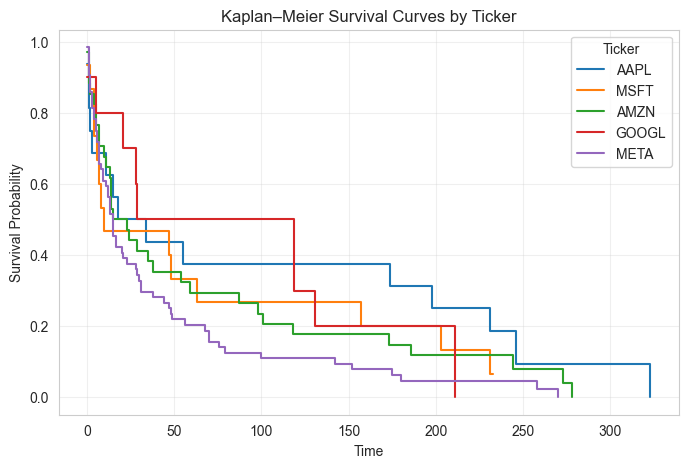

In [66]:
plt.figure(figsize=(8, 5))

horizon = 365

for ticker in tickers:
    temp_df = survival_df[survival_df["ticker"] == ticker].copy()

    last_date = temp_df["date"].max()
    temp_df.loc[temp_df["date"] == last_date, "price_event"] = 0

    temp_df = temp_df[temp_df["duration"] <= horizon]

    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=temp_df["duration"],
        event_observed=temp_df["price_event"],
        label=ticker
    )
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan–Meier Survival Curves by Ticker")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend(title="Ticker")
plt.grid(alpha=0.3)
plt.show()



What this Kaplan–Meier survival curve shows is that Meta is much more likely to experience a 5% price swing within 100 days compared to the other tickers.

That said, Microsoft stands out in the short term — it’s the most likely to hit a 5% move within the first ~30 days.

Apple, on the other hand, looks like the strongest “survivor” overall, with 5% swings taking the longest to occur.


Now let's see if we can find any beahviours in our data which influence price swings.'

In [67]:
survival_df.head()

,date,price_event,duration,ticker
0,2012-04-17,1,0,AAPL
1,2012-05-21,1,34,AAPL
2,2012-12-05,1,198,AAPL
3,2015-08-24,1,992,AAPL
4,2015-08-25,1,1,AAPL


In [68]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'ticker',
       'close_pct_daily_change', 'vol_pct_daily_change', 'vol_pct_5d',
       'day_of_month', 'day_of_week', 'week_of_year', 'month', 'up_day',
       'log_volume'],
      dtype='object')

In [69]:
# Connect (in-memory or to a local DB file)
con = duckdb.connect()

query = """

SELECT
    base.date,
    base.price_event,
    base.duration,
    base.ticker,

    df.volume,
    df.day_of_month,
    df.day_of_week,
    df.month,

FROM survival_df AS base
LEFT JOIN df ON df.date = base.date AND df.ticker = base.ticker

"""

cox_df = con.execute(query).fetchdf()

cox_df.head()

,date,price_event,duration,ticker,volume,day_of_month,day_of_week,month
0,2012-04-17,1,0,AAPL,"1,025.53",17,1,4
1,2012-05-21,1,34,AAPL,631.11,21,0,5
2,2012-12-05,1,198,AAPL,"1,044.64",5,2,12
3,2015-08-24,1,992,AAPL,648.83,24,0,8
4,2015-08-25,1,1,AAPL,414.41,25,1,8


In [70]:
for ticker in tickers:
    temp_df = cox_df[cox_df["ticker"] == ticker].copy()
    temp_df = temp_df[['price_event','duration','volume','day_of_month','day_of_week','month']]

    cph = CoxPHFitter()
    cph.fit(temp_df, duration_col='duration', event_col='price_event')
    print(f"{ticker}")
    cph.print_summary()

AAPL


<lifelines.CoxPHFitter: fitted with 21 total observations, 1 right-censored observations>
             duration col = 'duration'
                event col = 'price_event'
      baseline estimation = breslow
   number of observations = 21
number of events observed = 20
   partial log-likelihood = -42.64
         time fit was run = 2025-12-19 15:40:06 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
volume        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
day_of_month -0.03      0.97      0.03           -0.09            0.03                0.92                1.03
day_of_week   0.17      1.18      0.20           -0.23            0.56                0.80                1.75
month         0.00      1.00      0.07           -0.13            0.14                0.88                1.15

              cmp to     z    p  -log2(p)
covariate                                
volume          0.00  0.46 0.65      0.62
day_of_month    0.00 -1.02 0.31      1.70
day_of_week     0.00  0.82 0.41      1.29
month           0.00  0.07 0.95      0.08
---
Concordance = 0.56
Partial AIC = 93.27
log-likelihood ratio test = 1.33 on 4 df
-log2(p) of ll-ratio test = 0.22

MSFT


<lifelines.CoxPHFitter: fitted with 19 total observations, 1 right-censored observations>
             duration col = 'duration'
                event col = 'price_event'
      baseline estimation = breslow
   number of observations = 19
number of events observed = 18
   partial log-likelihood = -35.22
         time fit was run = 2025-12-19 15:40:06 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
volume        0.03      1.03      0.01            0.00            0.05                1.00                1.06
day_of_month  0.01      1.01      0.03           -0.05            0.07                0.95                1.07
day_of_week  -0.16      0.85      0.26           -0.67            0.35                0.51                1.43
month         0.06      1.06      0.09           -0.11            0.23                0.89                1.25

              cmp to     z    p  -log2(p)
covariate                                
volume          0.00  2.01 0.04      4.49
day_of_month    0.00  0.32 0.75      0.42
day_of_week     0.00 -0.61 0.54      0.88
month           0.00  0.64 0.52      0.94
---
Concordance = 0.61
Partial AIC = 78.44
log-likelihood ratio test = 5.02 on 4 df
-log2(p) of ll-ratio test = 1.81

AMZN


<lifelines.CoxPHFitter: fitted with 40 total observations, 1 right-censored observations>
             duration col = 'duration'
                event col = 'price_event'
      baseline estimation = breslow
   number of observations = 40
number of events observed = 39
   partial log-likelihood = -106.01
         time fit was run = 2025-12-19 15:40:06 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
volume        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
day_of_month -0.01      0.99      0.02           -0.05            0.03                0.95                1.03
day_of_week  -0.04      0.96      0.13           -0.30            0.22                0.74                1.25
month         0.11      1.12      0.06           -0.00            0.23                1.00                1.26

              cmp to     z    p  -log2(p)
covariate                                
volume          0.00  0.35 0.72      0.47
day_of_month    0.00 -0.44 0.66      0.60
day_of_week     0.00 -0.30 0.77      0.38
month           0.00  1.89 0.06      4.08
---
Concordance = 0.59
Partial AIC = 220.02
log-likelihood ratio test = 4.01 on 4 df
-log2(p) of ll-ratio test = 1.31

GOOGL


<lifelines.CoxPHFitter: fitted with 16 total observations, 1 right-censored observations>
             duration col = 'duration'
                event col = 'price_event'
      baseline estimation = breslow
   number of observations = 16
number of events observed = 15
   partial log-likelihood = -25.03
         time fit was run = 2025-12-19 15:40:06 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
volume        0.02      1.02      0.01           -0.01            0.05                0.99                1.05
day_of_month -0.00      1.00      0.04           -0.07            0.07                0.93                1.07
day_of_week  -0.16      0.85      0.29           -0.72            0.40                0.48                1.49
month         0.05      1.05      0.09           -0.12            0.22                0.88                1.24

              cmp to     z    p  -log2(p)
covariate                                
volume          0.00  1.24 0.22      2.21
day_of_month    0.00 -0.00 1.00      0.00
day_of_week     0.00 -0.57 0.57      0.81
month           0.00  0.55 0.58      0.78
---
Concordance = 0.64
Partial AIC = 58.06
log-likelihood ratio test = 7.13 on 4 df
-log2(p) of ll-ratio test = 2.95

META


<lifelines.CoxPHFitter: fitted with 68 total observations, 1 right-censored observations>
             duration col = 'duration'
                event col = 'price_event'
      baseline estimation = breslow
   number of observations = 68
number of events observed = 67
   partial log-likelihood = -218.23
         time fit was run = 2025-12-19 15:40:06 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
volume        0.00      1.00      0.00           -0.00            0.01                1.00                1.01
day_of_month -0.01      0.99      0.01           -0.03            0.02                0.97                1.02
day_of_week  -0.04      0.96      0.09           -0.22            0.13                0.80                1.14
month         0.02      1.02      0.04           -0.05            0.09                0.95                1.09

              cmp to     z    p  -log2(p)
covariate                                
volume          0.00  1.79 0.07      3.76
day_of_month    0.00 -0.39 0.70      0.52
day_of_week     0.00 -0.48 0.63      0.66
month           0.00  0.47 0.64      0.65
---
Concordance = 0.53
Partial AIC = 444.45
log-likelihood ratio test = 3.57 on 4 df
-log2(p) of ll-ratio test = 1.10

Looking at the Cox model summary for each ticker, we’re working with fairly narrow data, so there aren’t many features in play with.

That said, one thing that does stand out is volume. There are two cases where volume has a p-value below 0.05, and that’s for Microsoft. Meta comes close as well, but it doesn’t quite hit our alpha threshold of 0.05.

So overall, we can say there’s at least a weak or tangential relationship between trading volume and the likelihood of a price move occurring.


<lifelines.WeibullFitter:"Weibull_estimate", fitted with 20 total observations, 1 right-censored observations>
   number of observations = 20
number of events observed = 19
           log-likelihood = -119.39
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 186.94     77.86           34.34          339.54
rho_      0.57      0.11            0.36            0.78

         cmp to     z      p  -log2(p)
lambda_    1.00  2.39   0.02      5.88
rho_       1.00 -3.93 <0.005     13.54
---
AIC = 242.77

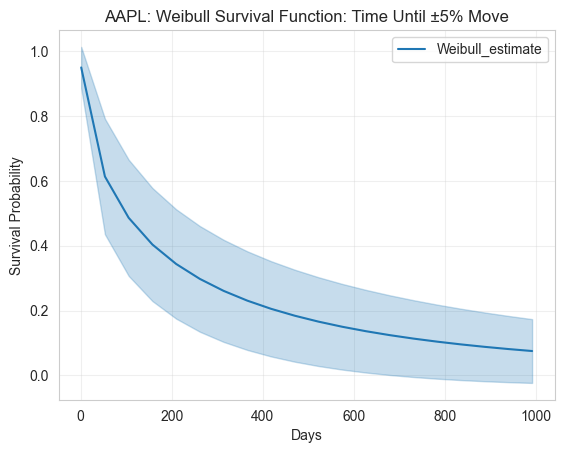

<lifelines.WeibullFitter:"Weibull_estimate", fitted with 18 total observations, 1 right-censored observations>
   number of observations = 18
number of events observed = 17
           log-likelihood = -105.71
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 170.70     87.09            0.01          341.38
rho_      0.50      0.09            0.32            0.68

         cmp to     z      p  -log2(p)
lambda_    1.00  1.95   0.05      4.28
rho_       1.00 -5.50 <0.005     24.63
---
AIC = 215.41

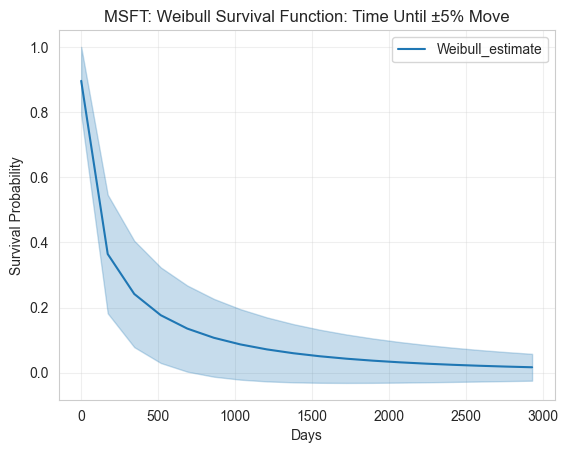

<lifelines.WeibullFitter:"Weibull_estimate", fitted with 39 total observations, 1 right-censored observations>
   number of observations = 39
number of events observed = 38
           log-likelihood = -216.60
               hypothesis = lambda_ != 1, rho_ != 1

---
         coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 98.09     28.63           41.97          154.21
rho_     0.58      0.07            0.44            0.73

         cmp to     z      p  -log2(p)
lambda_    1.00  3.39 <0.005     10.49
rho_       1.00 -5.63 <0.005     25.75
---
AIC = 437.20

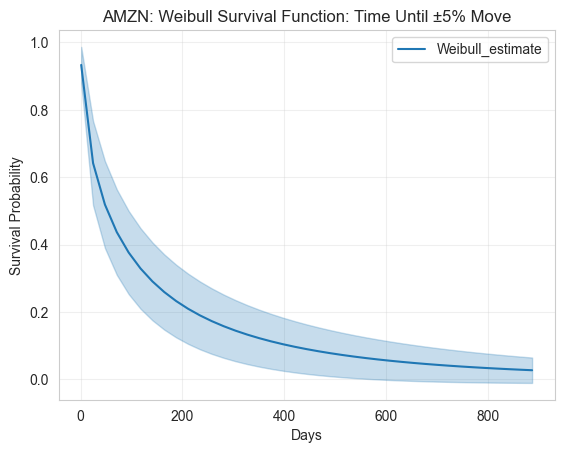

<lifelines.WeibullFitter:"Weibull_estimate", fitted with 15 total observations, 1 right-censored observations>
   number of observations = 15
number of events observed = 14
           log-likelihood = -95.46
               hypothesis = lambda_ != 1, rho_ != 1

---
          coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 323.87    103.45          121.12          526.63
rho_      0.86      0.19            0.49            1.24

         cmp to     z      p  -log2(p)
lambda_    1.00  3.12 <0.005      9.12
rho_       1.00 -0.71   0.48      1.06
---
AIC = 194.92

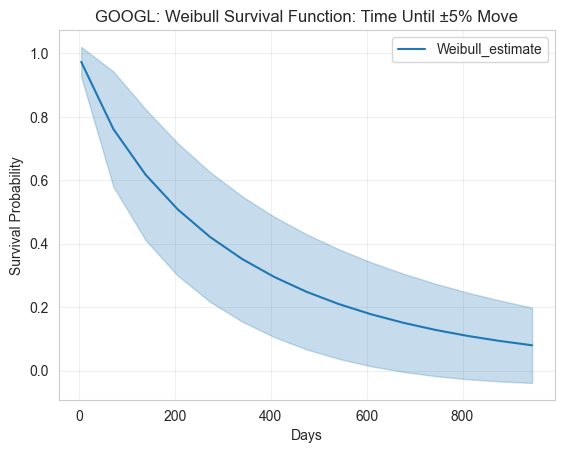

<lifelines.WeibullFitter:"Weibull_estimate", fitted with 67 total observations, 1 right-censored observations>
   number of observations = 67
number of events observed = 66
           log-likelihood = -328.81
               hypothesis = lambda_ != 1, rho_ != 1

---
         coef  se(coef)  coef lower 95%  coef upper 95%
lambda_ 46.06     10.08           26.31           65.81
rho_     0.59      0.05            0.49            0.70

         cmp to     z      p  -log2(p)
lambda_    1.00  4.47 <0.005     16.97
rho_       1.00 -7.54 <0.005     44.23
---
AIC = 661.62

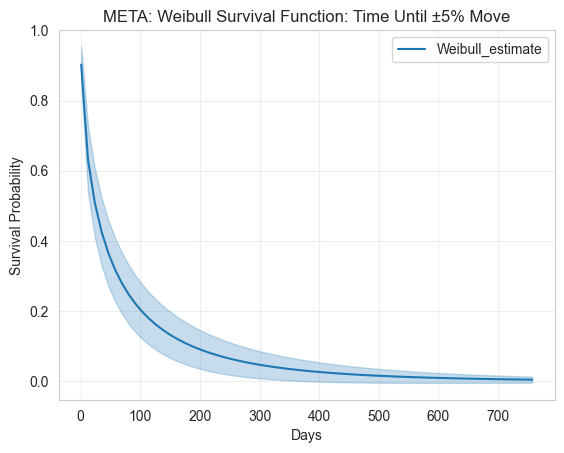

In [71]:
wf_df = cox_df[cox_df["duration"] > 0].copy()

for ticker in tickers:
    temp_df = wf_df[wf_df["ticker"] == ticker].copy()

    wf = WeibullFitter()
    wf.fit(
        durations=temp_df["duration"],
        event_observed=temp_df["price_event"]
    )

    wf.print_summary()

    wf.plot_survival_function()
    plt.title(f"{ticker}: Weibull Survival Function: Time Until ±5% Move")
    plt.xlabel("Days")
    plt.ylabel("Survival Probability")
    plt.grid(alpha=0.3)
    plt.show()


Looking at the Weibull survival curves by ticker, we can break things down pretty cleanly by stock:

- Apple has roughly a 50% chance of experiencing a 5% move within about 150 days, putting it firmly in the middle of the group.
- Microsoft takes a bit longer, with the 50% probability point landing closer to 200 days.
- Amazon moves much faster, reaching a 50% chance of a 5% move in around 75 days.
- Google is one of the slower movers, with a median time to a 5% move of roughly 210 days.
- Meta stands out as the most volatile, with a 50% chance of a 5% move in just over 40 days.

Overall, this lines up well with what we’d expect intuitively: Meta and Amazon tend to move quickly, while Apple, Microsoft, and Google take much longer to hit that 5% threshold.


Let's see if there are any features which influence price movement outcome with a Cox hazard function

In [72]:
features = [
    "volume",
    "day_of_month",
    "day_of_week",
    "month"
]

X = cox_df[features]

y = Surv.from_dataframe(
    event="price_event",
    time="duration",
    data=cox_df
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [73]:
from sksurv.linear_model import CoxPHSurvivalAnalysis

cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)


,alpha,0
,ties,'breslow'
,n_iter,100
,tol,1e-09
,verbose,0


In [74]:
from sksurv.metrics import concordance_index_censored

risk_scores = -cox.predict(X_test)

ci = concordance_index_censored(
    y_test["price_event"],
    y_test["duration"],
    risk_scores
)[0]

print("C-index:", round(ci, 3))

C-index: 0.467


Based on the concordance index with a value of below 0.5, this basically tells us that the prediction is pretty random, as in the features that we put into our model don't really describe or have any influence on the outcome of price movements.

**So we could conclude that the trend is more important than the features of the data in predicting price movements.**

# Ranking Models


Build ranking model that is capable of ranking given stocks in descending order in terms of possible daily gains from each stock.



In [75]:
rank_df = df.copy()

In [76]:
rank_df.sort_values(by=['date'], ascending=True).head(5)

,date,open,high,low,close,volume,ticker,close_pct_daily_change,vol_pct_daily_change,vol_pct_5d,day_of_month,day_of_week,week_of_year,month,up_day,log_volume
0,2010-01-04,6.40,6.43,6.37,6.42,493.73,AAPL,0.27,NaN,NaN,4,0,1,1,1,2.69
12006,2010-01-04,15.57,15.64,15.50,15.57,78.17,GOOGL,-0.03,NaN,NaN,4,0,1,1,0,1.89
4002,2010-01-04,22.88,23.24,22.86,23.13,38.41,MSFT,1.08,NaN,NaN,4,0,1,1,1,1.58
8004,2010-01-04,6.81,6.83,6.66,6.70,152.00,AMZN,-1.72,NaN,NaN,4,0,1,1,0,2.18
8005,2010-01-05,6.67,6.77,6.59,6.73,177.04,AMZN,0.94,0.16,NaN,5,1,1,1,1,2.25


In [77]:
rank_df = rank_df[['date','ticker','close_pct_daily_change','vol_pct_daily_change','log_volume']]
rank_df.head()

,date,ticker,close_pct_daily_change,vol_pct_daily_change,log_volume
0,2010-01-04,AAPL,0.27,NaN,2.69
1,2010-01-05,AAPL,-0.10,0.22,2.78
2,2010-01-06,AAPL,-1.59,-0.08,2.74
3,2010-01-07,AAPL,-0.55,-0.14,2.68
4,2010-01-08,AAPL,0.80,-0.06,2.65


To rank tickers by their returns, we need a relevance column first. Since we care about returns, that relevance will come straight from the close percent daily change.

The plan is to look at the distribution of daily percent changes and use that to bucket observations into different levels of relevance. Bigger positive moves get higher relevance, smaller (or negative) moves get lower relevance.

Before we lock any buckets in, let’s see what the distribution actually looks like.


0.0379083745260648


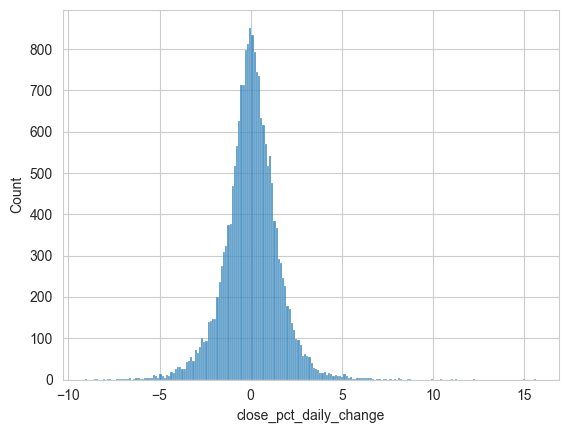

In [78]:
sns.histplot(data=rank_df, x='close_pct_daily_change')
print(rank_df['close_pct_daily_change'].median())

We have a tidy normal distribution with some small outliers but we don't particularily want to cut the data up into equal parts for relevance as we don't want to assign any higher relevance to negative returns.

Instead we'll do this:
- Any return below zero gets the lowest relevance.
- For returns above zero, we split the remaining data into two buckets.
- The highest relevance is assigned to the strongest positive returns.
- The mid-level relevance sits between zero and the median positive return value.

This gives us a simple relevance scale that’s directly tied to return strength.


In [79]:
rank_df['close_pct_daily_change'].describe()

count   19,411.00
mean         0.03
std          1.49
min         -9.08
25%         -0.75
50%          0.04
75%          0.86
max         15.64
Name: close_pct_daily_change, dtype: float64

In [80]:
median_positive_return = rank_df['close_pct_daily_change'][rank_df['close_pct_daily_change'] > 0].median()

In [81]:
print(f"Lowest Relevance Bin (1): <= 0")
print(f"Mid Relevance Bin (2): 0 -> {median_positive_return}")
print(f"Highest Relevance Bin (3): >= {median_positive_return}")

Lowest Relevance Bin (1): <= 0
Mid Relevance Bin (2): 0 -> 0.8372228369635741
Highest Relevance Bin (3): >= 0.8372228369635741


In [82]:
bins = [-10, 0, median_positive_return, 16]
lab = [1, 2, 3]

rank_df['relevance'] = pd.cut(rank_df['close_pct_daily_change'], bins=bins, labels=lab, include_lowest=True)
rank_df['relevance'] = rank_df['relevance'].astype(int)

In [83]:
rank_df.isna().sum()

date                      0
ticker                    0
close_pct_daily_change    0
vol_pct_daily_change      5
log_volume                0
relevance                 0
dtype: int64

In [84]:
rank_df['relevance'].value_counts()

relevance
1    9454
2    4979
3    4978
Name: count, dtype: int64

In [85]:
rank_df.head()

,date,ticker,close_pct_daily_change,vol_pct_daily_change,log_volume,relevance
0,2010-01-04,AAPL,0.27,NaN,2.69,2
1,2010-01-05,AAPL,-0.10,0.22,2.78,1
2,2010-01-06,AAPL,-1.59,-0.08,2.74,1
3,2010-01-07,AAPL,-0.55,-0.14,2.68,1
4,2010-01-08,AAPL,0.80,-0.06,2.65,2


In [86]:
X = rank_df.iloc[:,2 :-1]
y = rank_df['relevance']

group = rank_df.groupby('date').size().to_list()

train_data = lgb.Dataset(X, label=y, group=group)

params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'ndcg_eval_at': [1, 3],
    'verbose': -1
}

model = lgb.train(params, train_data, num_boost_round=20)

predictions = model.predict(X)
rank_df['lgb_predicted_relevance'] = predictions

y_true = rank_df[['relevance']]
y_score = rank_df[['lgb_predicted_relevance']]



In [87]:
print("Precision@3:", hf.precision_at_k(y_true, y_score, 3))

Precision@3: 1.0


We're getting very high precision as we're testing on trained data. Let's see what accuracy gives us

In [88]:
print(average_precision_score(y_true, y_score))

0.487043428983566


Let's take an example of 2025-11-25 and see how our ranking compares to our actual relevance ranking

In [89]:
example_date = rank_df[rank_df['date'] == '2025-11-25']

print(
    example_date[['date', 'ticker','lgb_predicted_relevance']].sort_values(['lgb_predicted_relevance','date'], ascending=[False,True]).head(3))

            date ticker  lgb_predicted_relevance
12003 2025-11-25   AMZN                     2.55
19408 2025-11-25   META                     2.55
3999  2025-11-25   AAPL                     0.21


Text(0.5, 1.0, 'Predicted vs Actual on example date')

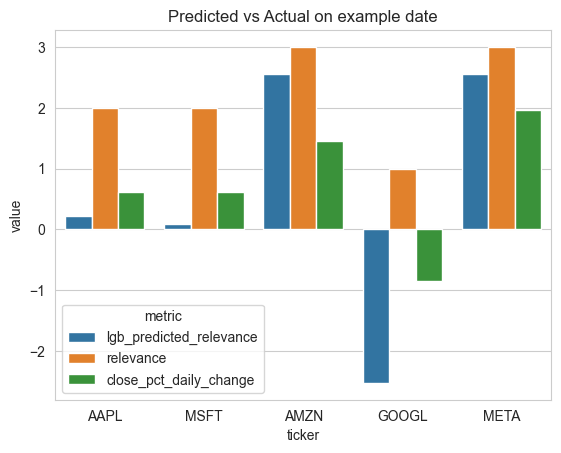

In [90]:
plot_df = example_date.melt(
    id_vars="ticker",
    value_vars=["lgb_predicted_relevance", "relevance","close_pct_daily_change"],
    var_name="metric",
    value_name="value"
)

sns.barplot(
    data=plot_df,
    x="ticker",
    y="value",
    hue="metric"
).set_title(f"Predicted vs Actual on example date")